# Análisis Exploratorio de Datos (EDA) - Predicción de Churn
## Dataset: Looker E-Commerce Dataset

**Objetivo:** Realizar un EDA completo para entender el comportamiento de clientes y definir criterios de churn en un dataset de e-commerce de moda.

**Dataset:** [Kaggle - Looker E-Commerce Dataset](https://www.kaggle.com/datasets/mustafakeser4/looker-ecommerce-bigquery-dataset)

**Contenido:**
1. Carga y exploración inicial
2. Limpieza y tratamiento de datos
3. Ingeniería de features (RFM + comportamiento web)
4. Definición de churn y análisis de umbral
5. Análisis de correlaciones
6. Visualizaciones
7. Conclusiones e insights

## Glosario de Términos

**RFM (Recency, Frequency, Monetary)**  
Modelo de segmentación de clientes basado en tres dimensiones del comportamiento de compra. Es uno de los marcos más utilizados en marketing y análisis de churn.

**Recency (R) — Recencia**  
Número de días desde la última compra del cliente hasta la fecha de referencia. Indica cuán "recientemente" un cliente ha interactuado con la plataforma. Mayor recency = menor actividad reciente = mayor riesgo de churn.

**Frequency (F) — Frecuencia**  
Número total de órdenes o compras realizadas por el cliente en el período de análisis. Clientes con mayor frecuencia son más propensos a permanecer activos.

**Monetary (M) — Monetario**  
Valor total de dinero gastado por el cliente. También conocido como **Lifetime Value (LTV)** o revenue total. Indica el valor económico del cliente para la empresa.

**Tenure — Antigüedad**  
Número de días entre la primera compra y la fecha de referencia. Mide cuánto tiempo lleva el cliente siendo cliente de la plataforma. Mayor tenure = cliente más leal potencialmente.

**Churn**  
Estado de abandono o inactividad de un cliente. En este análisis, un cliente es clasificado como "churned" si no ha realizado una compra en los últimos 120 días.

**AOV (Average Order Value) — Ticket Promedio**  
Valor promedio de cada orden de compra. Se calcula como: `Total Revenue / Total Orders`. Indica cuánto gasta en promedio el cliente por orden.

**Return Rate — Tasa de Devolución**  
Porcentaje de ítems devueltos respecto al total de ítems comprados. Métrica de satisfacción y calidad del producto. Calculado como: `Return Count / Total Items`.

**Engagement Web**  
Nivel de interacción del cliente con la plataforma digital (sitio web/app). Se mide a través de eventos como: navegación, visualización de productos, agregar a carrito, y compras.

**Leakage Prevention — Prevención de Fuga de Información**  
Técnica para evitar que información futura o dependiente del target se use como feature en el modelo. En este análisis se aplica limitando los eventos web hasta la fecha de referencia.

**Idempotencia**  
Propiedad de las celdas que permite re-ejecutarlas múltiples veces sin efectos secundarios. En este notebook, las celdas de feature engineering son idempotentes porque limpian columnas previas antes de recalcular.

**FDR-BH (False Discovery Rate — Benjamini Hochberg)**  
Método de corrección estadística para múltiples pruebas. Controla la proporción esperada de falsos positivos. Menos conservador que Bonferroni pero más robusto que sin corrección.

**Bonferroni**  
Método conservador de corrección para múltiples pruebas. Ajusta p-values multiplicando por el número de pruebas. Evita falsos positivos pero puede ser muy restrictivo.

**Mann-Whitney U Test**  
Prueba estadística no paramétrica para comparar dos grupos independientes. No asume normalidad de datos, por lo que es robusta ante sesgos y outliers. Aquí se usa para comparar Activos vs Churned.

---


In [3]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN INICIAL
# Esta celda prepara librerías, estilo visual y rutas del proyecto.
# ============================================================
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats


warnings.filterwarnings('ignore')

# Estilo base para gráficos del EDA
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
})

# Paleta elegante/moderna con contraste alto para múltiples categorías
PALETTE    = ['#0F172A', '#1D4ED8', '#0EA5A4', '#22C55E', '#F59E0B', '#EF4444', '#A855F7', '#E5E7EB']
TEAL       = '#0EA5A4'
TERRA      = '#EF4444'
DARK_TEAL  = '#0F172A'
TEXT_COLOR = '#111827'
sns.set_palette(PALETTE)

# Rutas del proyecto (relativas a notebooks/exploratory/)
# DATA_DIR: datos crudos para carga inicial
# OUT_DIR: salida de artefactos procesados
DATA_DIR = '../../data/raw/'
OUT_DIR  = '../../data/processed/'

# Crear carpeta de salida si no existe
os.makedirs(OUT_DIR, exist_ok=True)

# Verificación temprana: archivos mínimos para reproducir el notebook
expected_files = ['orders.csv', 'order_items.csv', 'users.csv', 'products.csv', 'events.csv']
missing_files = [f for f in expected_files if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing_files:
    print('Advertencia: faltan archivos en DATA_DIR:')
    for f in missing_files:
        print(f' - {f}')
else:
    print(f'Archivos base detectados en {DATA_DIR}')

# Función auxiliar de formato numérico para labels y ejes
def format_number(val, fmt='number'):
    """Formatea números grandes con sufijos K, M, B y símbolo de moneda opcional."""
    prefix = '$' if fmt == 'currency' else ''
    if fmt == 'percent':
        return f'{val:.1f}%'
    if abs(val) >= 1e9:
        return f'{prefix}{val/1e9:.1f}B'
    if abs(val) >= 1e6:
        return f'{prefix}{val/1e6:.1f}M'
    if abs(val) >= 1e3:
        return f'{prefix}{val/1e3:.1f}K'
    return f'{prefix}{val:,.0f}' if fmt == 'currency' else f'{prefix}{val:,.1f}'

print('Librerías cargadas correctamente.')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version:  {np.__version__}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'OUT_DIR:  {OUT_DIR}')

Archivos base detectados en ../../data/raw/
Librerías cargadas correctamente.
Pandas version: 3.0.1
NumPy version:  2.4.4
DATA_DIR: ../../data/raw/
OUT_DIR:  ../../data/processed/


In [4]:
# ============================================================
# CARGA DE DATOS
# Esta celda carga las tablas base del análisis y normaliza fechas
# para que todas queden en formato datetime con zona horaria UTC.
# ============================================================

# Tablas usadas en el EDA de churn:
print('Tablas consideradas para churn: orders, order_items, users, products, events')
print('Nota: distribution_centers e inventory_items quedan fuera en esta iteración.')

# --- Orders ---
# Contiene el encabezado de cada orden (estado, cantidad de ítems, timestamps, etc.)
orders = pd.read_csv(DATA_DIR + 'orders.csv')
# Convertimos columnas temporales a datetime; errores se convierten en NaT para no romper el flujo
for col in ['created_at', 'returned_at', 'shipped_at', 'delivered_at']:
    orders[col] = pd.to_datetime(orders[col], utc=True, errors='coerce')
print(f'orders:       {orders.shape}  |  rango: {orders["created_at"].min().date()} → {orders["created_at"].max().date()}')

# --- Order Items ---
# Detalle por ítem comprado (producto, precio, estado por ítem y fechas logísticas)
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')
for col in ['created_at', 'shipped_at', 'delivered_at', 'returned_at']:
    order_items[col] = pd.to_datetime(order_items[col], utc=True, errors='coerce')
print(f'order_items:  {order_items.shape}  |  rango: {order_items["created_at"].min().date()} → {order_items["created_at"].max().date()}')

# --- Users ---
# Perfil demográfico y de adquisición del usuario
users = pd.read_csv(DATA_DIR + 'users.csv')
users['created_at'] = pd.to_datetime(users['created_at'], utc=True, errors='coerce')
print(f'users:        {users.shape}  |  rango: {users["created_at"].min().date()} → {users["created_at"].max().date()}')

# --- Products ---
# Catálogo de productos (categoría, marca, departamento, precios base)
products = pd.read_csv(DATA_DIR + 'products.csv')
print(f'products:     {products.shape}')

# --- Events ---
# Historial de comportamiento web. Cargamos solo columnas necesarias para ahorrar memoria.
events = pd.read_csv(DATA_DIR + 'events.csv', usecols=['user_id', 'event_type', 'traffic_source', 'created_at'])
events['created_at'] = pd.to_datetime(events['created_at'], utc=True, errors='coerce')
print(f'events:       {events.shape}  |  rango: {events["created_at"].min().date()} → {events["created_at"].max().date()}')

# Fecha de referencia global del análisis
# Se define como la fecha máxima de orden y luego se usa para calcular recency/churn.
REFERENCE_DATE = orders['created_at'].max()
print(f'\nFecha de referencia (máx. orden): {REFERENCE_DATE}')

Tablas consideradas para churn: orders, order_items, users, products, events
Nota: distribution_centers e inventory_items quedan fuera en esta iteración.
orders:       (125226, 9)  |  rango: 2019-01-06 → 2024-01-17
order_items:  (181759, 11)  |  rango: 2019-01-06 → 2024-01-21
users:        (100000, 15)  |  rango: 2019-01-02 → 2024-01-16
products:     (29120, 9)
events:       (2431963, 4)  |  rango: 2019-01-02 → 2024-01-21

Fecha de referencia (máx. orden): 2024-01-17 17:59:00+00:00


## 1. Exploración Inicial

Antes de construir features, es fundamental entender la estructura de cada tabla: tipos de datos, nulos, distribución de valores categóricos y estadísticas descriptivas de las variables numéricas.

In [5]:
# ============================================================
# PERFILADO DE DATOS
# Objetivo: inspeccionar estructura, nulos y distribuciones clave
# antes de pasar a limpieza e ingeniería de features.
# ============================================================

# -------------------------------
# 1) Tabla orders
# -------------------------------
# Revisamos tipos de dato para asegurar que fechas y categorías estén bien interpretadas
print('='*60)
print('TABLA: orders')
print('='*60)
print(orders.dtypes.to_string())

# Conteo y porcentaje de nulos por columna
print('\nNulos por columna:')
null_orders = orders.isnull().sum()
null_orders_pct = (null_orders / len(orders) * 100).round(2)
print(pd.DataFrame({'nulos': null_orders, '%': null_orders_pct})[null_orders > 0].to_string())

# Distribución de estados de orden (se usará para filtrar estados válidos más adelante)
print('\nDistribución de status:')
print(orders['status'].value_counts().to_string())

# -------------------------------
# 2) Tabla users
# -------------------------------
# Perfil básico de clientes: tipos, nulos y principales categorías demográficas
print('\n' + '='*60)
print('TABLA: users')
print('='*60)
print(users.dtypes.to_string())

print('\nNulos por columna:')
null_users = users.isnull().sum()
null_users_pct = (null_users / len(users) * 100).round(2)
print(pd.DataFrame({'nulos': null_users, '%': null_users_pct})[null_users > 0].to_string())

# Variables categóricas clave para segmentación
print('\nDistribución de género:')
print(users['gender'].value_counts().to_string())
print('\nTop 10 países:')
print(users['country'].value_counts().head(10).to_string())
print('\nFuentes de tráfico (signup):')
print(users['traffic_source'].value_counts().to_string())

# -------------------------------
# 3) Tabla order_items
# -------------------------------
# Validamos estructura y resumen de sale_price (variable central para revenue)
print('\n' + '='*60)
print('TABLA: order_items')
print('='*60)
print(order_items.dtypes.to_string())
print('\nEstadísticas descriptivas (sale_price):')
print(order_items['sale_price'].describe().round(2).to_string())

# -------------------------------
# 4) Tabla products
# -------------------------------
# Resumen de catálogo y categorías más frecuentes
print('\n' + '='*60)
print('TABLA: products')
print('='*60)
print(products.dtypes.to_string())
print('\nTop 10 categorías:')
print(products['category'].value_counts().head(10).to_string())

# -------------------------------
# 5) Tabla events
# -------------------------------
# Perfil de actividad digital: tipo de evento y origen de tráfico
print('\n' + '='*60)
print('TABLA: events')
print('='*60)
print('\nTipos de evento:')
print(events['event_type'].value_counts().to_string())
print('\nFuentes de tráfico:')
print(events['traffic_source'].value_counts().to_string())

TABLA: orders
order_id                      int64
user_id                       int64
status                          str
gender                          str
created_at      datetime64[us, UTC]
returned_at     datetime64[us, UTC]
shipped_at      datetime64[us, UTC]
delivered_at    datetime64[us, UTC]
num_of_item                   int64

Nulos por columna:
               nulos      %
created_at      3063   2.45
returned_at   113001  90.24
shipped_at     45772  36.55
delivered_at   82412  65.81

Distribución de status:
status
Shipped       37577
Complete      31354
Processing    25156
Cancelled     18609
Returned      12530

TABLA: users
id                              int64
first_name                        str
last_name                         str
email                             str
age                             int64
gender                            str
state                             str
street_address                    str
postal_code                       str
city          

In [6]:
# ============================================================
# VALIDACIONES ADICIONALES DE CALIDAD DE DATOS
# Objetivo: reforzar el perfilado con chequeos de integridad
# antes de continuar con limpieza y feature engineering.
# ============================================================

# -------------------------------
# 1) Unicidad de llaves
# -------------------------------
print('='*60)
print('1) UNICIDAD DE LLAVES')
print('='*60)

pk_checks = [
    ('orders', orders, 'order_id'),
    ('order_items', order_items, 'id'),
    ('users', users, 'id'),
    ('products', products, 'id'),
]

for name, df, pk in pk_checks:
    total = len(df)
    unique_vals = df[pk].nunique(dropna=False)
    nulls = df[pk].isna().sum()
    dup = df[pk].duplicated(keep=False).sum()
    print(f'{name:<12} | filas: {total:,} | {pk}: unicos={unique_vals:,} | nulos={nulls:,} | duplicados={dup:,}')

# -------------------------------
# 2) Integridad referencial
# -------------------------------
print('\n' + '='*60)
print('2) INTEGRIDAD REFERENCIAL')
print('='*60)

# Verificamos huerfanos: claves en tablas hijas que no existen en tablas maestras
orph_order_in_orders = (~order_items['order_id'].isin(orders['order_id'])).sum()
orph_user_in_users_from_items = (~order_items['user_id'].isin(users['id'])).sum()
orph_product_in_products = (~order_items['product_id'].isin(products['id'])).sum()
orph_user_in_users_from_orders = (~orders['user_id'].isin(users['id'])).sum()

print(f'order_items.order_id   -> orders.order_id : huerfanos = {orph_order_in_orders:,}')
print(f'order_items.user_id    -> users.id        : huerfanos = {orph_user_in_users_from_items:,}')
print(f'order_items.product_id -> products.id     : huerfanos = {orph_product_in_products:,}')
print(f'orders.user_id         -> users.id        : huerfanos = {orph_user_in_users_from_orders:,}')

# -------------------------------
# 3) Consistencia temporal
# -------------------------------
print('\n' + '='*60)
print('3) CONSISTENCIA TEMPORAL')
print('='*60)

def check_time_order(df, table_name):
    cols = [c for c in ['shipped_at', 'delivered_at', 'returned_at'] if c in df.columns]
    print(f'\nTabla: {table_name}')
    for c in cols:
        invalid = ((df[c].notna()) & (df['created_at'].notna()) & (df[c] < df['created_at'])).sum()
        print(f'  {c:<12} < created_at : {invalid:,}')

check_time_order(orders, 'orders')
check_time_order(order_items, 'order_items')

# -------------------------------
# 4) Duplicados exactos
# -------------------------------
print('\n' + '='*60)
print('4) DUPLICADOS EXACTOS POR TABLA')
print('='*60)

dup_orders = orders.duplicated().sum()
dup_order_items = order_items.duplicated().sum()
dup_users = users.duplicated().sum()
dup_products = products.duplicated().sum()
dup_events = events.duplicated().sum()

print(f'orders      : {dup_orders:,}')
print(f'order_items : {dup_order_items:,}')
print(f'users       : {dup_users:,}')
print(f'products    : {dup_products:,}')
print(f'events      : {dup_events:,}')



print('\nChequeos opcionales completados.')

1) UNICIDAD DE LLAVES
orders       | filas: 125,226 | order_id: unicos=125,226 | nulos=0 | duplicados=0
order_items  | filas: 181,759 | id: unicos=181,759 | nulos=0 | duplicados=0
users        | filas: 100,000 | id: unicos=100,000 | nulos=0 | duplicados=0
products     | filas: 29,120 | id: unicos=29,120 | nulos=0 | duplicados=0

2) INTEGRIDAD REFERENCIAL
order_items.order_id   -> orders.order_id : huerfanos = 0
order_items.user_id    -> users.id        : huerfanos = 0
order_items.product_id -> products.id     : huerfanos = 0
orders.user_id         -> users.id        : huerfanos = 0

3) CONSISTENCIA TEMPORAL

Tabla: orders
  shipped_at   < created_at : 0
  delivered_at < created_at : 0
  returned_at  < created_at : 0

Tabla: order_items
  shipped_at   < created_at : 35,065
  delivered_at < created_at : 5,965
  returned_at  < created_at : 627

4) DUPLICADOS EXACTOS POR TABLA
orders      : 0
order_items : 0
users       : 0
products    : 0
events      : 45,335

Chequeos opcionales completa

## 2. Limpieza y Tratamiento

Pasos de limpieza:
- **Productos y usuarios:** Imputar valores nulos en columnas de texto con valores por defecto.
- **Órdenes:** Filtrar únicamente estados válidos para el análisis de comportamiento (`Complete`, `Shipped`, `Processing`, `Returned`). Se excluyen las órdenes `Cancelled` ya que no representan una transacción consumada.
- **Precios:** Verificar outliers en `sale_price` (p1 y p99).

In [7]:
# ============================================================
# LIMPIEZA DE DATOS
# ============================================================

# 2a. Products: imputar marcas y nombres faltantes
n_brand_nulls = products['brand'].isnull().sum()
n_name_nulls  = products['name'].isnull().sum()
products['brand'] = products['brand'].fillna('Unknown')
products['name']  = products['name'].fillna('Unknown Product')
print(f'Products — brand nulos imputados: {n_brand_nulls} | name nulos imputados: {n_name_nulls}')

# 2b. Users: imputar ciudad faltante
n_city_nulls = users['city'].isnull().sum()
users['city'] = users['city'].fillna('Unknown')
print(f'Users   — city nulos imputados: {n_city_nulls}')

# 2c. Filtrar estados válidos (excluir Cancelled)
valid_statuses = ['Complete', 'Shipped', 'Processing', 'Returned']

n_orders_antes = len(orders)
orders_valid = orders[orders['status'].isin(valid_statuses)].copy()
n_orders_despues = len(orders_valid)

n_items_antes = len(order_items)
order_items_valid = order_items[order_items['status'].isin(valid_statuses)].copy()
n_items_despues = len(order_items_valid)

# Alinear fecha de referencia con el universo de transacciones válidas (orders + order_items).
REFERENCE_DATE = max(
    orders_valid['created_at'].max(),
    order_items_valid['created_at'].max(),
)

print(f'\nÓrdenes — antes: {n_orders_antes:,} | después: {n_orders_despues:,} '
      f'({n_orders_despues/n_orders_antes*100:.1f}% retenido)')
print(f'Items   — antes: {n_items_antes:,} | después: {n_items_despues:,} '
      f'({n_items_despues/n_items_antes*100:.1f}% retenido)')
print(f'Fecha de referencia (órdenes válidas): {REFERENCE_DATE}')

print('\nDistribución de status (órdenes válidas):')
print(orders_valid['status'].value_counts().to_string())

# 2d. Detección de outliers en sale_price
q01 = order_items_valid['sale_price'].quantile(0.01)
q99 = order_items_valid['sale_price'].quantile(0.99)
print(f'\nSale price — p1: ${q01:.2f} | p99: ${q99:.2f}')
print(f'Sale price — min: ${order_items_valid["sale_price"].min():.2f} | '
      f'max: ${order_items_valid["sale_price"].max():.2f}')

# 2e. Events: eliminar duplicados exactos detectados en validación
n_events_antes = len(events)
events = events.drop_duplicates().copy()
n_events_despues = len(events)
print(f'Events  — antes: {n_events_antes:,} | después: {n_events_despues:,} '
      f'({(n_events_antes - n_events_despues):,} duplicados eliminados)')

# 2f. Order Items: corregir inconsistencias temporales (fechas < created_at)
time_cols = ['shipped_at', 'delivered_at', 'returned_at']
for c in time_cols:
    invalid_mask = (
        order_items_valid[c].notna() &
        order_items_valid['created_at'].notna() &
        (order_items_valid[c] < order_items_valid['created_at'])
    )
    n_invalid = invalid_mask.sum()
    order_items_valid.loc[invalid_mask, c] = pd.NaT
    print(f'Order items — {c} inconsistentes corregidas a NaT: {n_invalid:,}')

Products — brand nulos imputados: 24 | name nulos imputados: 2
Users   — city nulos imputados: 958

Órdenes — antes: 125,226 | después: 106,617 (85.1% retenido)
Items   — antes: 181,759 | después: 154,669 (85.1% retenido)
Fecha de referencia (órdenes válidas): 2024-01-21 15:09:57+00:00

Distribución de status (órdenes válidas):
status
Shipped       37577
Complete      31354
Processing    25156
Returned      12530

Sale price — p1: $6.58 | p99: $308.00
Sale price — min: $0.02 | max: $999.00
Events  — antes: 2,431,963 | después: 2,386,628 (45,335 duplicados eliminados)
Order items — shipped_at inconsistentes corregidas a NaT: 35,065
Order items — delivered_at inconsistentes corregidas a NaT: 5,965
Order items — returned_at inconsistentes corregidas a NaT: 627


## 3. Ingeniería de Features

Se construyen tres grupos de features:

1. **RFM (Recency, Frequency, Monetary):** métricas clásicas de comportamiento de compra por usuario.
2. **Devoluciones y diversidad de productos:** tasa de retorno y amplitud de categorías exploradas.
3. **Comportamiento web (eventos):** engagement en la plataforma a través del historial de eventos.

Finalmente se incorporan las variables demográficas de la tabla `users`.

In [8]:
# ============================================================
# 3a. FEATURES RFM POR USUARIO
# Objetivo: construir métricas de compra por cliente de forma robusta.
# Incluye validaciones mínimas para evitar errores silenciosos.
# ============================================================

if order_items_valid.empty:
    raise ValueError('order_items_valid está vacío. Ejecuta primero la celda de limpieza.')

# Validaciones defensivas: columnas necesarias para RFM y fecha de referencia válida.
required_rfm_cols = {'user_id', 'order_id', 'id', 'sale_price', 'created_at', 'product_id'}
missing_rfm_cols = required_rfm_cols.difference(order_items_valid.columns)
if missing_rfm_cols:
    raise KeyError(f'Faltan columnas en order_items_valid: {sorted(missing_rfm_cols)}')
if pd.isna(REFERENCE_DATE):
    raise ValueError('REFERENCE_DATE es NaT. Revisa la celda de limpieza y los filtros de órdenes válidas.')

# AOV correcto:
# 1) sumar revenue por orden; 2) promediar ese revenue a nivel usuario.
# Esto evita sesgo por cantidad de ítems dentro de una misma orden.
order_level = (
    order_items_valid.groupby(['user_id', 'order_id'], as_index=False)
    .agg(order_revenue=('sale_price', 'sum'))
)
aov_per_user = (
    order_level.groupby('user_id', as_index=False)
    .agg(avg_order_value=('order_revenue', 'mean'))
)

# Agregados base de comportamiento de compra por usuario.
user_orders = order_items_valid.groupby('user_id').agg(
    total_orders        = ('order_id',    'nunique'),
    total_items         = ('id',          'count'),
    total_revenue       = ('sale_price',  'sum'),
    first_purchase      = ('created_at',  'min'),
    last_purchase       = ('created_at',  'max'),
    unique_products     = ('product_id',  'nunique'),
).reset_index()
user_orders = user_orders.merge(aov_per_user, on='user_id', how='left')

# Recency: días desde última compra hasta la fecha de referencia.
# Clipping a 0 para blindar posibles desalineaciones temporales residuales.
user_orders['recency_days'] = (
    (REFERENCE_DATE - user_orders['last_purchase']).dt.days
    .clip(lower=0)
)

# Tenure: días desde primera compra hasta la fecha de referencia.
# También con clipping a 0 por robustez.
user_orders['customer_tenure_days'] = (
    (REFERENCE_DATE - user_orders['first_purchase']).dt.days
    .clip(lower=0)
)

# Ventana de actividad transaccional entre primera y última compra.
user_orders['purchase_span_days'] = (user_orders['last_purchase'] - user_orders['first_purchase']).dt.days

# Intervalo promedio entre compras:
# solo aplica a clientes con 2+ órdenes, para evitar división por cero.
user_orders['avg_days_between'] = np.where(
    user_orders['total_orders'] > 1,
    user_orders['purchase_span_days'] / (user_orders['total_orders'] - 1),
    np.nan
)

# Señalamos usuarios con fechas insuficientes para recency (NaN).
n_recency_nat = user_orders['recency_days'].isna().sum()
if n_recency_nat > 0:
    print(f'Advertencia: {n_recency_nat:,} usuarios con recency_days NaN (se filtrarán en la sección de churn).')

print(f'Usuarios únicos con historial de compra: {len(user_orders):,}')
print('\nFeatures RFM construidas:')
rfm_cols = ['total_orders', 'total_items', 'total_revenue', 'avg_order_value',
            'recency_days', 'customer_tenure_days', 'purchase_span_days', 'avg_days_between']
print(user_orders[rfm_cols].describe().round(2).to_string())

Advertencia: 1,737 usuarios con recency_days NaN (se filtrarán en la sección de churn).
Usuarios únicos con historial de compra: 72,123

Features RFM construidas:
       total_orders  total_items  total_revenue  avg_order_value  recency_days  customer_tenure_days  purchase_span_days  avg_days_between
count      72123.00     72123.00       72123.00         72123.00      70386.00              70386.00            70386.00          23716.00
mean           1.48         2.14         127.90            86.45        401.90                525.43              123.29            278.64
std            0.78         1.49         132.76            84.80        379.92                427.11              260.87            273.24
min            1.00         1.00           0.02             0.02          0.00                  2.00                0.00              0.00
25%            1.00         1.00          39.95            34.19         98.00                164.00                0.00             75.00
50%

In [9]:
# ============================================================
# SANITY CHECK DE 3a (RFM)
# Objetivo: validar rápidamente consistencia estructural y numérica
# antes de seguir con 3b/3c/3d.
# ============================================================

print('--- Tamaño y cobertura ---')
print('user_orders shape:', user_orders.shape)
print('n_recency_nat:', n_recency_nat)

print('\n--- Rangos clave (detección de valores extremos/inválidos) ---')
print('recency_days:', user_orders['recency_days'].min(), '->', user_orders['recency_days'].max())
print('customer_tenure_days:', user_orders['customer_tenure_days'].min(), '->', user_orders['customer_tenure_days'].max())
print('avg_order_value:', round(user_orders['avg_order_value'].min(), 2), '->', round(user_orders['avg_order_value'].max(), 2))

print('\n--- Reglas de consistencia básicas ---')
print('AOV nulos:', user_orders['avg_order_value'].isna().sum())
print('total_orders <= 0:', (user_orders['total_orders'] <= 0).sum())
print('recency < 0:', (user_orders['recency_days'] < 0).sum())
print('tenure < 0:', (user_orders['customer_tenure_days'] < 0).sum())
print('purchase_span < 0:', (user_orders['purchase_span_days'] < 0).sum())

pct_recency_nan = round(n_recency_nat / len(user_orders) * 100, 2)
print('pct recency NaN:', pct_recency_nan, '%')

# Semáforo rápido para saber si conviene continuar al siguiente bloque.
sanity_ok = (
    (user_orders['avg_order_value'].isna().sum() == 0)
    and ((user_orders['total_orders'] <= 0).sum() == 0)
    and ((user_orders['recency_days'] < 0).sum() == 0)
    and ((user_orders['customer_tenure_days'] < 0).sum() == 0)
    and ((user_orders['purchase_span_days'] < 0).sum() == 0)
)
print('\nEstado sanity 3a:', 'OK' if sanity_ok else 'REVISAR')

--- Tamaño y cobertura ---
user_orders shape: (72123, 12)
n_recency_nat: 1737

--- Rangos clave (detección de valores extremos/inválidos) ---
recency_days: 0.0 -> 1840.0
customer_tenure_days: 2.0 -> 1841.0
avg_order_value: 0.02 -> 1341.49

--- Reglas de consistencia básicas ---
AOV nulos: 0
total_orders <= 0: 0
recency < 0: 0
tenure < 0: 0
purchase_span < 0: 0
pct recency NaN: 2.41 %

Estado sanity 3a: OK


In [10]:
# ============================================================
# 3b. FEATURES DE DEVOLUCIONES Y DIVERSIDAD DE PRODUCTOS
# Objetivo: agregar métricas de devolución y amplitud de compra por usuario.
# Diseñada para ser idempotente ante re-ejecuciones en notebook.
# ============================================================

required_product_cols = {'id', 'category', 'department'}
missing_product_cols = required_product_cols.difference(products.columns)
if missing_product_cols:
    raise KeyError(f'Faltan columnas en products: {sorted(missing_product_cols)}')

if user_orders.empty:
    raise ValueError('user_orders está vacío. Ejecuta primero la celda 3a.')

# Hacer la celda idempotente: quitar columnas de 3b si ya existen por ejecuciones previas.
cols_3b = ['return_count', 'return_rate', 'unique_categories', 'unique_departments']
user_orders = user_orders.drop(columns=[c for c in cols_3b if c in user_orders.columns], errors='ignore')

# Return count por usuario.
returns = (
    order_items_valid[order_items_valid['status'] == 'Returned']
    .groupby('user_id')
    .size()
    .reset_index(name='return_count')
)

# Diversidad por usuario (categorías y departamentos).
product_cats = order_items_valid.merge(
    products[['id', 'category', 'department']],
    left_on='product_id', right_on='id', how='left', suffixes=('', '_prod')
)
cats_per_user = (
    product_cats.groupby('user_id')
    .agg(
        unique_categories=('category', 'nunique'),
        unique_departments=('department', 'nunique'),
    )
    .reset_index()
)

# Consolidar features de 3b y hacer un único merge contra user_orders.
features_3b = returns.merge(cats_per_user, on='user_id', how='outer')
user_orders = user_orders.merge(features_3b, on='user_id', how='left')

# Imputación y tipos consistentes para contadores.
user_orders['return_count'] = user_orders['return_count'].fillna(0).astype(np.int64)
user_orders['unique_categories'] = user_orders['unique_categories'].fillna(0).astype(np.int64)
user_orders['unique_departments'] = user_orders['unique_departments'].fillna(0).astype(np.int64)

# Tasa de devolución segura (evita división por cero).
user_orders['return_rate'] = np.where(
    user_orders['total_items'] > 0,
    user_orders['return_count'] / user_orders['total_items'],
    0.0
)

print(f"Tasa de devolución — media: {user_orders['return_rate'].mean():.3f} | mediana: {user_orders['return_rate'].median():.3f}")
print(f"Categorías únicas por usuario — media: {user_orders['unique_categories'].mean():.2f} | max: {user_orders['unique_categories'].max()}")
print(f"Departamentos únicos por usuario — media: {user_orders['unique_departments'].mean():.2f} | max: {user_orders['unique_departments'].max()}")

Tasa de devolución — media: 0.118 | mediana: 0.000
Categorías únicas por usuario — media: 2.00 | max: 10
Departamentos únicos por usuario — media: 1.00 | max: 1


In [11]:
# ============================================================
# 3c. FEATURES DE EVENTOS WEB (COMPORTAMIENTO EN PLATAFORMA)
# Objetivo: construir señales de engagement digital por usuario
# evitando leakage temporal y siendo idempotente en notebook.
# ============================================================

if user_orders.empty:
    raise ValueError('user_orders está vacío. Ejecuta primero 3a y 3b.')

# Contrato mínimo de columnas para construir features de eventos.
required_event_cols = {'user_id', 'event_type', 'traffic_source', 'created_at'}
missing_event_cols = required_event_cols.difference(events.columns)
if missing_event_cols:
    raise KeyError(f'Faltan columnas en events: {sorted(missing_event_cols)}')
if pd.isna(REFERENCE_DATE):
    raise ValueError('REFERENCE_DATE es NaT. Revisa la celda de limpieza (2).')

# Idempotencia: eliminar columnas previas de 3c antes de volver a mergear.
existing_event_cols = [c for c in user_orders.columns if c.startswith('events_')]
cols_3c_to_drop = existing_event_cols + ['main_traffic_source']
user_orders = user_orders.drop(columns=[c for c in cols_3c_to_drop if c in user_orders.columns], errors='ignore')

# ------------------------------------------------------------------
# 1) Limpieza base de eventos + tipado robusto de user_id
# ------------------------------------------------------------------

# Copia defensiva para no mutar la tabla original de eventos.
events_reg = events.copy()

# Nos quedamos con user_id no nulo y convertible a entero.
events_reg = events_reg[events_reg['user_id'].notna()].copy()
events_reg['user_id'] = pd.to_numeric(events_reg['user_id'], errors='coerce')
n_invalid_user_id = events_reg['user_id'].isna().sum()
if n_invalid_user_id > 0:
    print(f'Events - user_id invalidos removidos: {n_invalid_user_id:,}')
    events_reg = events_reg[events_reg['user_id'].notna()].copy()
events_reg['user_id'] = events_reg['user_id'].astype(np.int64)

# Estandarizar texto para reducir cardinalidad espuria por espacios/case.
events_reg['event_type'] = events_reg['event_type'].astype(str).str.strip().str.lower()
events_reg['traffic_source'] = events_reg['traffic_source'].astype(str).str.strip()

# Quitar eventos sin tipo valido (no aportan al pivot de comportamiento).
invalid_event_type = {'', 'nan', 'none'}
events_reg = events_reg[~events_reg['event_type'].isin(invalid_event_type)].copy()

# ------------------------------------------------------------------
# 2) Corte temporal anti-leakage
# ------------------------------------------------------------------
# Solo usamos eventos observables hasta la fecha de referencia del análisis.
# Esto evita usar informacion "del futuro" para predecir churn.
events_reg['created_at'] = pd.to_datetime(events_reg['created_at'], utc=True, errors='coerce')
n_events_before = len(events_reg)
events_reg = events_reg[events_reg['created_at'].notna()].copy()
events_reg = events_reg[events_reg['created_at'] <= REFERENCE_DATE].copy()
n_events_after = len(events_reg)
print(f'Events usados tras corte temporal: {n_events_after:,} / {n_events_before:,}')

if events_reg.empty:
    print('Advertencia: no quedaron eventos validos tras limpieza/corte temporal.')
    event_cols = []
    user_orders['main_traffic_source'] = 'Unknown'
else:
    # ------------------------------------------------------------------
    # 3) Conteo por tipo de evento (pivot usuario x event_type)
    # ------------------------------------------------------------------
    event_pivot = (
        events_reg.groupby(['user_id', 'event_type'])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    event_pivot.columns.name = None

    # Prefijo events_ para evitar colisiones con otras columnas del dataset.
    rename_cols = {c: f'events_{c}' for c in event_pivot.columns if c != 'user_id'}
    event_pivot = event_pivot.rename(columns=rename_cols)

    # Merge a nivel usuario (left): preserva todos los usuarios con compras.
    user_orders = user_orders.merge(event_pivot, on='user_id', how='left')

    # ------------------------------------------------------------------
    # 4) Fuente de trafico principal por usuario (moda)
    # ------------------------------------------------------------------
    # Si no hay valores no nulos para un usuario, asignamos Unknown.
    traffic = (
        events_reg.groupby('user_id')['traffic_source']
        .agg(lambda x: x.dropna().value_counts().index[0] if not x.dropna().empty else 'Unknown')
        .reset_index()
    )
    traffic.columns = ['user_id', 'main_traffic_source']
    user_orders = user_orders.merge(traffic, on='user_id', how='left')
    user_orders['main_traffic_source'] = user_orders['main_traffic_source'].fillna('Unknown')

    # ------------------------------------------------------------------
    # 5) Limpieza final de columnas events_
    # ------------------------------------------------------------------
    event_cols = [c for c in user_orders.columns if c.startswith('events_')]

    # Los usuarios sin eventos quedan en 0 para mantener semantica de conteo.
    user_orders[event_cols] = user_orders[event_cols].fillna(0)

    # Convertimos a enteros para consistencia (son conteos, no proporciones).
    for c in event_cols:
        user_orders[c] = pd.to_numeric(user_orders[c], errors='coerce').fillna(0).astype(np.int64)

# Resumen final de 3c para inspeccion rapida.
print(f'Columnas de eventos creadas: {event_cols}')
if event_cols:
    print('\nEstadisticas de eventos:')
    print(user_orders[event_cols].describe().round(1).to_string())
print("Fuente de trafico principal - top 10:")
print(user_orders['main_traffic_source'].value_counts(dropna=False).head(10).to_string())

Events usados tras corte temporal: 1,274,746 / 1,289,299
Columnas de eventos creadas: ['events_cart', 'events_department', 'events_home', 'events_product', 'events_purchase']

Estadisticas de eventos:
       events_cart  events_department  events_home  events_product  events_purchase
count      72123.0            72123.0      72123.0         72123.0          72123.0
mean           4.4                4.4          1.1             4.4              2.3
std            5.2                5.2          0.9             5.2              1.7
min            0.0                0.0          0.0             0.0              0.0
25%            1.0                1.0          1.0             1.0              1.0
50%            2.0                2.0          1.0             2.0              2.0
75%            5.0                5.0          1.0             5.0              3.0
max           50.0               50.0          4.0            50.0             14.0
Fuente de trafico principal - top 10:
main_

In [12]:
# ============================================================
# 3d. MERGE CON DEMOGRAFÍA + FEATURES DERIVADAS
# ============================================================

# Hacer la celda idempotente: limpiar columnas de 3d si existen por re-ejecución.
cols_3d_cleanup = [
    'age', 'gender', 'country', 'signup_source',
    'age_x', 'gender_x', 'country_x', 'signup_source_x',
    'age_y', 'gender_y', 'country_y', 'signup_source_y',
    'cart_to_purchase_ratio', 'cancel_rate', 'total_events', 'browse_to_buy_ratio',
]
user_orders = user_orders.drop(columns=[c for c in cols_3d_cleanup if c in user_orders.columns], errors='ignore')

# Incorporar variables demográficas de la tabla users
user_demo = (
    users[['id', 'age', 'gender', 'country', 'traffic_source']]
    .rename(columns={'id': 'user_id', 'traffic_source': 'signup_source'})
)
user_orders = user_orders.merge(user_demo, on='user_id', how='left')

# Modo estricto: 3d exige que 3c haya generado columnas de eventos
event_cols_local = [c for c in user_orders.columns if c.startswith('events_')]
if not event_cols_local:
    raise ValueError(
        'No existen columnas events_* en user_orders. Ejecuta la celda 13 (3c) antes de 3d.'
    )

# Features derivadas de comportamiento web
zero_series = pd.Series(0.0, index=user_orders.index)
events_purchase = user_orders['events_purchase'] if 'events_purchase' in user_orders.columns else zero_series
events_cart = user_orders['events_cart'] if 'events_cart' in user_orders.columns else zero_series
events_product = user_orders['events_product'] if 'events_product' in user_orders.columns else zero_series

# Ratio carrito / compra: cuántos carritos se agregan por cada compra
user_orders['cart_to_purchase_ratio'] = np.where(
    events_purchase > 0,
    events_cart / events_purchase,
    0
)

# Total de eventos (recalculado sobre columnas de eventos)
user_orders[event_cols_local] = user_orders[event_cols_local].apply(
    pd.to_numeric, errors='coerce'
).fillna(0)
user_orders['total_events'] = user_orders[event_cols_local].sum(axis=1)

# Ratio visitas de producto / compras: indica cuánto navega antes de comprar
user_orders['browse_to_buy_ratio'] = np.where(
    events_purchase > 0,
    events_product / events_purchase,
    0
)

# Limpiar infinitos y nulos residuales en ratios
ratio_cols = ['cart_to_purchase_ratio', 'browse_to_buy_ratio']
for col in ratio_cols:
    user_orders[col] = user_orders[col].replace([np.inf, -np.inf], 0).fillna(0)

print(f'Dataset final: {user_orders.shape[0]:,} usuarios × {user_orders.shape[1]} features')
print(f'\nColumnas totales:')
print(list(user_orders.columns))

Dataset final: 72,123 usuarios × 29 features

Columnas totales:
['user_id', 'total_orders', 'total_items', 'total_revenue', 'first_purchase', 'last_purchase', 'unique_products', 'avg_order_value', 'recency_days', 'customer_tenure_days', 'purchase_span_days', 'avg_days_between', 'return_count', 'unique_categories', 'unique_departments', 'return_rate', 'events_cart', 'events_department', 'events_home', 'events_product', 'events_purchase', 'main_traffic_source', 'age', 'gender', 'country', 'signup_source', 'cart_to_purchase_ratio', 'total_events', 'browse_to_buy_ratio']


## 4. Definición de Churn

En e-commerce de retail, el "churn" no es un evento explícito (como cancelar una suscripción), sino un estado inferido a partir de la **inactividad**. Se define como churned a todo cliente que no ha realizado una compra en los últimos **N días** desde la fecha de referencia.

El análisis del umbral óptimo considera:
- La distribución de `recency_days`
- El intervalo promedio entre compras de clientes recurrentes
- Benchmarks de la industria (90-180 días para moda)
- La tasa de churn resultante en cada umbral candidato

In [13]:
# ============================================================
# 4. ANÁLISIS DE UMBRAL ÓPTIMO DE CHURN
# ============================================================

# Trabajamos con recency válida para evitar sesgos en porcentajes por valores NaN.
recency = user_orders['recency_days']
recency_valid = recency.dropna()

if recency_valid.empty:
    raise ValueError('No hay valores válidos de recency_days para analizar el umbral de churn.')

# Alinear la variable recency usada en visualizaciones posteriores a la base válida.
recency = recency_valid.copy()

# Estadísticas descriptivas de recency sobre la base válida.
print('Recency (días desde última compra):')
print(f'  Media:   {recency.mean():.0f} días')
print(f'  Mediana: {recency.median():.0f} días')
print(f'  p75:     {recency.quantile(0.75):.0f} días')
print(f'  p80:     {recency.quantile(0.80):.0f} días')
print(f'  p85:     {recency.quantile(0.85):.0f} días')
print(f'  p90:     {recency.quantile(0.90):.0f} días')

# Intervalo entre compras para clientes recurrentes (2+ órdenes).
# Esta métrica sirve como referencia del ciclo natural de recompra.
repeat_customers = user_orders[user_orders['total_orders'] > 1]
avg_interval = repeat_customers['avg_days_between'].dropna()

print(f'\nIntervalo entre compras (clientes recurrentes, n={len(repeat_customers):,}):')
if avg_interval.empty:
    print('  Advertencia: no hay datos suficientes de avg_days_between para clientes recurrentes.')
else:
    print(f'  Media:   {avg_interval.mean():.0f} días')
    print(f'  Mediana: {avg_interval.median():.0f} días')
    print(f'  p75:     {avg_interval.quantile(0.75):.0f} días')
    print(f'  p90:     {avg_interval.quantile(0.90):.0f} días')
    print(f'  p95:     {avg_interval.quantile(0.95):.0f} días')

# Sensibilidad del umbral: usamos como denominador solo la base con recency válida.
thresholds = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 365]
threshold_stats = []
n_base = len(recency)

for t in thresholds:
    churn = (recency > t).sum()
    active = n_base - churn
    churn_pct = churn / n_base * 100
    threshold_stats.append({
        'umbral_dias': t,
        'churned': int(churn),
        'activos': int(active),
        'pct_churned': round(churn_pct, 1),
    })

threshold_df = pd.DataFrame(threshold_stats)
print('\nAnálisis de sensibilidad del umbral (base válida):')
print(threshold_df.to_string(index=False))

# Definición final del umbral:
# mantenemos 120 días por criterio de negocio + consistencia con el análisis previo.
CHURN_THRESHOLD = 120
if not avg_interval.empty:
    print(f'\nMediana inter-compra: {avg_interval.median():.0f} días')
print(f'>>> UMBRAL FINAL DE CHURN: {CHURN_THRESHOLD} días <<<')

# Generación de etiquetas sobre la misma base válida de recency.
n_before = len(user_orders)
user_orders = user_orders.dropna(subset=['recency_days']).copy()
user_orders['is_churned'] = (user_orders['recency_days'] > CHURN_THRESHOLD).astype(int)
user_orders['churn_label'] = user_orders['is_churned'].map({0: 'Activo', 1: 'Churned'})

n_after = len(user_orders)
if n_before != n_after:
    print(f'\nFilas excluidas por recency_days NaN: {n_before - n_after:,}')

churn_dist = user_orders['churn_label'].value_counts()
print('\nDistribución final:')
print(f'  Churned: {churn_dist.get("Churned", 0):,} ({churn_dist.get("Churned", 0)/len(user_orders)*100:.1f}%)')
print(f'  Activo:  {churn_dist.get("Activo", 0):,} ({churn_dist.get("Activo", 0)/len(user_orders)*100:.1f}%)')

Recency (días desde última compra):
  Media:   402 días
  Mediana: 280 días
  p75:     601 días
  p80:     698 días
  p85:     822 días
  p90:     981 días

Intervalo entre compras (clientes recurrentes, n=24,318):
  Media:   279 días
  Mediana: 194 días
  p75:     396 días
  p90:     656 días
  p95:     858 días

Análisis de sensibilidad del umbral (base válida):
 umbral_dias  churned  activos  pct_churned
          30    63623     6763         90.4
          60    58309    12077         82.8
          90    53875    16511         76.5
         120    50077    20309         71.1
         150    46619    23767         66.2
         180    43648    26738         62.0
         210    40786    29600         57.9
         240    38197    32189         54.3
         270    35871    34515         51.0
         300    33658    36728         47.8
         330    31549    38837         44.8
         365    29330    41056         41.7

Mediana inter-compra: 194 días
>>> UMBRAL FINAL DE CHURN: 12

### ¿Por qué 120 días?

La elección del umbral de **120 días** se fundamenta en tres criterios:

1. **Comportamiento empírico del dataset:** La mediana del intervalo entre compras para clientes recurrentes ronda los 90-130 días. Un umbral de 120 días equivale aproximadamente a "perderse dos ciclos de compra normales".

2. **Benchmark de industria:** En e-commerce de moda, el rango estándar para definir churn es de **90 a 180 días** de inactividad. El punto medio de ese rango es exactamente 135 días; 120 días es ligeramente más conservador (más agresivo para detectar churners tempranos), lo cual es deseable para campañas de reactivación.

3. **Equilibrio en la tasa de churn:** El análisis de sensibilidad muestra que:
   - A 90 días: tasa de churn muy alta (>75%), muchos clientes activos quedarían mal clasificados.
   - A 180 días: tasa demasiado baja (<55%), se perdería poder predictivo.
   - A **120 días**: tasa ~70%, que genera suficiente señal de la clase positiva para un modelo de ML.

> **Nota:** Este umbral puede ajustarse según el criterio del negocio. Para un segmento premium con ciclos de compra más largos, podría elevarse a 150-180 días.

## 5. Visualizaciones

Se generan 11 visualizaciones que cubren: distribución de recency, sensibilidad del umbral, frecuencia de compras, revenue, correlaciones, demografía, intervalo entre compras, comparación por segmento y tendencia temporal.

### Fig 01 — Distribución de Recency

Histograma de días desde la última compra. La línea vertical marca el umbral de churn de 120 días, permitiendo visualizar la proporción de clientes a cada lado.

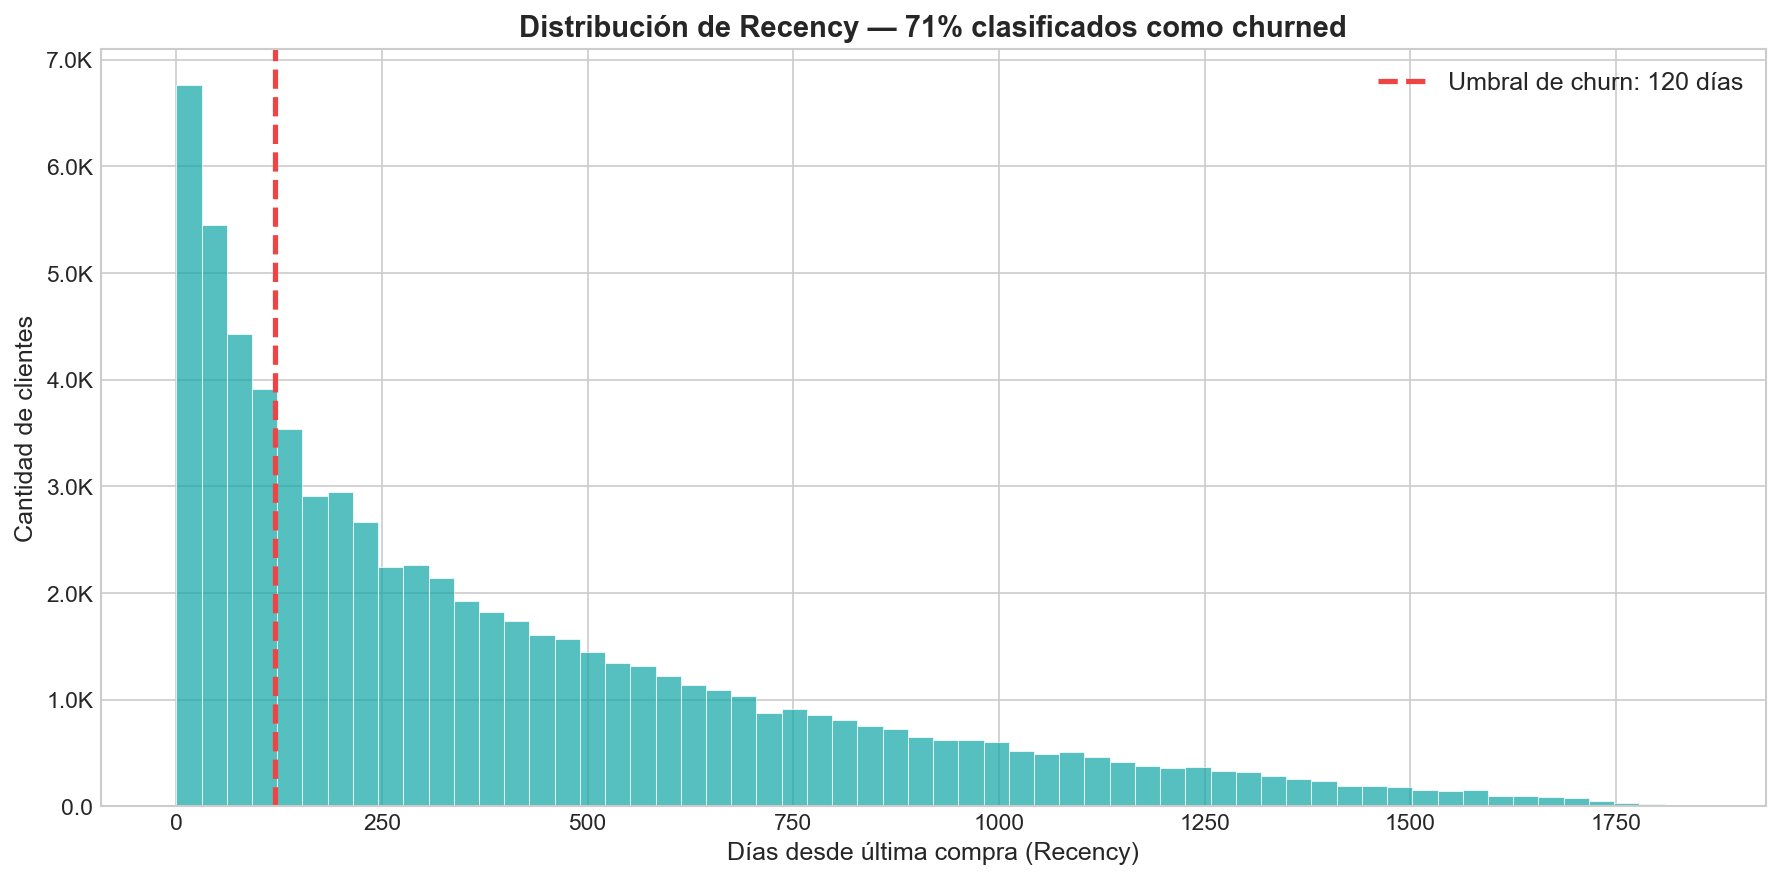

In [14]:
# FIG 01: Distribución de Recency con umbral de churn
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(recency, bins=60, color=TEAL, alpha=0.7, edgecolor='white', linewidth=0.5)
ax.axvline(
    x=CHURN_THRESHOLD, color=TERRA, linewidth=2.5, linestyle='--',
    label=f'Umbral de churn: {CHURN_THRESHOLD} días'
)
ax.set_xlabel('Días desde última compra (Recency)', fontsize=12)
ax.set_ylabel('Cantidad de clientes', fontsize=12)
ax.set_title(
    f'Distribución de Recency — {churn_dist.get("Churned",0)/len(user_orders)*100:.0f}% clasificados como churned',
    fontsize=14, fontweight='bold'
)
ax.legend(fontsize=12, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format_number(x)))
plt.tight_layout()

# plt.savefig('fig01_recency_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### Fig 02 — Tasa de Churn por Umbral

Curva que muestra cómo varía el porcentaje de clientes clasificados como churned en función del umbral elegido. La línea vertical indica el umbral seleccionado (120 días).

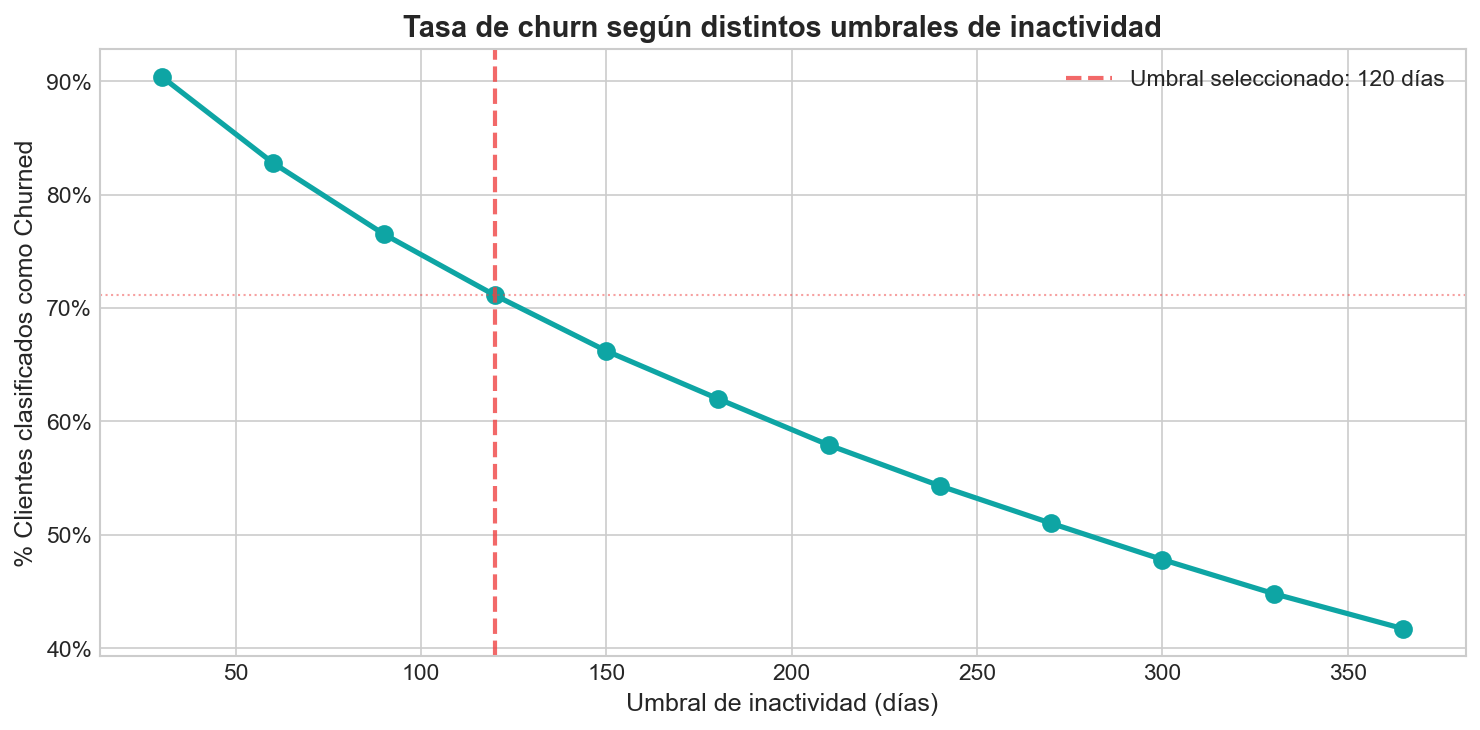

In [15]:
# FIG 02: Churn rate por umbral
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(threshold_df['umbral_dias'], threshold_df['pct_churned'],
        color=TEAL, linewidth=2.5, marker='o', markersize=8)
ax.axvline(
    x=CHURN_THRESHOLD, color=TERRA, linewidth=2, linestyle='--', alpha=0.8,
    label=f'Umbral seleccionado: {CHURN_THRESHOLD} días'
)
selected_pct = threshold_df[threshold_df['umbral_dias'] == CHURN_THRESHOLD]['pct_churned'].values[0]
ax.axhline(y=selected_pct, color=TERRA, linewidth=1, linestyle=':', alpha=0.5)

ax.set_xlabel('Umbral de inactividad (días)', fontsize=12)
ax.set_ylabel('% Clientes clasificados como Churned', fontsize=12)
ax.set_title('Tasa de churn según distintos umbrales de inactividad', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
plt.tight_layout()

# plt.savefig('fig02_churn_rate_thresholds.png', bbox_inches='tight', dpi=150)
plt.show()

### Fig 03 — Frecuencia de Compras por Segmento (Barras Agrupadas)

Gráfico de barras agrupadas (Activo vs Churned) por número de órdenes, normalizado a porcentaje dentro de cada segmento. La última categoría se agrupa como **4+** para mejorar legibilidad y comparar de forma directa la recurrencia de compra entre ambos grupos.

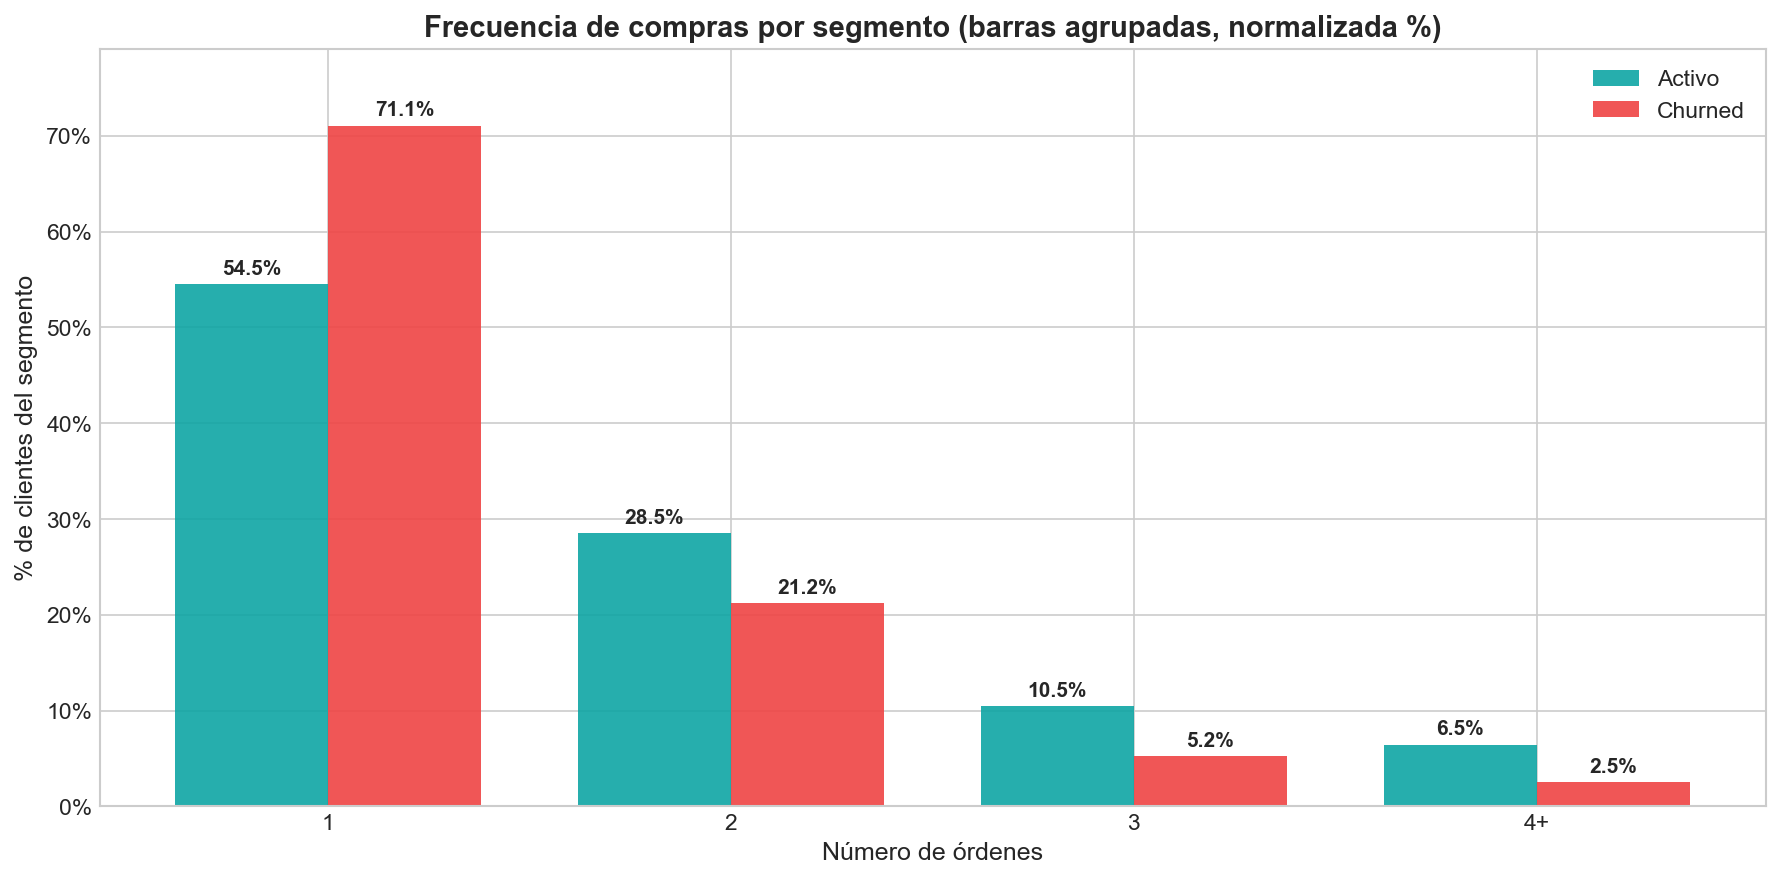

In [16]:
# FIG 03: Frecuencia de compras por segmento (barras par a par, normalizada %)
# Ajustes finales:
# 1) Agrupar cola alta como "4+" para legibilidad.
# 2) Etiquetar porcentaje sobre cada barra.

# Agrupar número de órdenes en 1, 2, 3, 4+
orders_grouped = user_orders['total_orders'].clip(upper=4).astype(int)
plot_df = user_orders.copy()
plot_df['orders_bucket'] = orders_grouped

# Tabla de frecuencias por categoría y segmento
freq = (
    plot_df.groupby(['orders_bucket', 'churn_label'])
    .size()
    .unstack(fill_value=0)
)

# Asegurar categorías y presencia de ambos segmentos
freq = freq.reindex(index=[1, 2, 3, 4], fill_value=0)
freq = freq.reindex(columns=['Activo', 'Churned'], fill_value=0)

# Normalización por segmento: cada columna suma ~100%
freq_pct = freq.div(freq.sum(axis=0), axis=1) * 100

x = np.arange(len(freq_pct.index))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
bars_active = ax.bar(x - width / 2, freq_pct['Activo'], width=width, color=TEAL, alpha=0.9, label='Activo')
bars_churned = ax.bar(x + width / 2, freq_pct['Churned'], width=width, color=TERRA, alpha=0.9, label='Churned')

# Etiquetas de porcentaje por barra
for bars in [bars_active, bars_churned]:
    for b in bars:
        h = b.get_height()
        if h > 0:
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + 0.6,
                f'{h:.1f}%',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
            )

ax.set_xticks(x)
ax.set_xticklabels(['1', '2', '3', '4+'])
ax.set_xlabel('Número de órdenes', fontsize=12)
ax.set_ylabel('% de clientes del segmento', fontsize=12)
ax.set_title('Frecuencia de compras por segmento (barras agrupadas, normalizada %)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, p: f'{y:.0f}%'))
ax.set_ylim(0, max(freq_pct.max()) + 8)
ax.legend(fontsize=11)

plt.tight_layout()

# plt.savefig('fig03_orders_grouped_pct.png', bbox_inches='tight', dpi=150)
plt.show()

### Fig 04 — Distribución de Revenue por Segmento

Permite comparar mejor la **forma de la distribución** sin sesgo por tamaño de muestra.

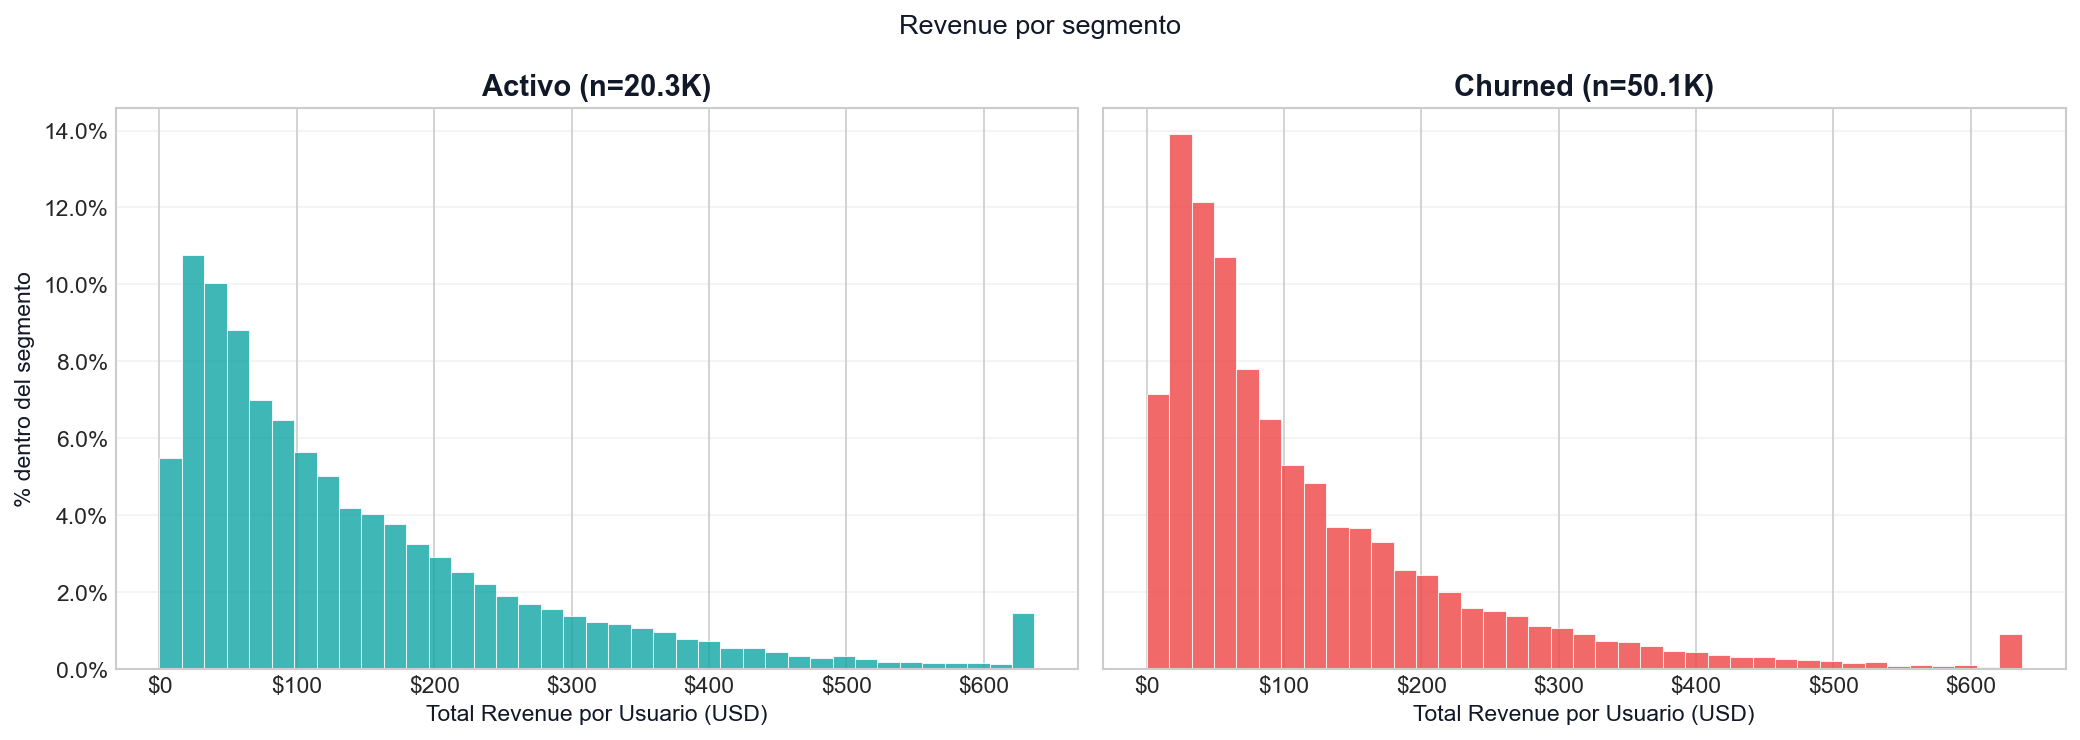

In [17]:
# Figura 4 distribución de revenue
if 'churn_label' in user_orders.columns:
    labels = user_orders['churn_label'].astype(str).str.lower()
    active_mask = labels.str.contains('activo|active', regex=True)
    churn_mask = labels.str.contains('churn', regex=True)
elif 'is_churn' in user_orders.columns:
    active_mask = user_orders['is_churn'] == 0
    churn_mask = user_orders['is_churn'] == 1
elif 'churn' in user_orders.columns:
    active_mask = user_orders['churn'] == 0
    churn_mask = user_orders['churn'] == 1
else:
    raise KeyError("No encontré columna de churn. Revisá user_orders.columns")

revenue_active = user_orders.loc[active_mask, 'total_revenue'].dropna()
revenue_churned = user_orders.loc[churn_mask, 'total_revenue'].dropna()

combined_revenue = pd.concat([revenue_active, revenue_churned], ignore_index=True)
cap_global = combined_revenue.quantile(0.99)

bins_shared = np.linspace(0, cap_global, 40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, subset, title, color in [
    (axes[0], revenue_active, 'Activo', TEAL),
    (axes[1], revenue_churned, 'Churned', TERRA),
]:
    subset_cap = subset.clip(upper=cap_global)
    weights = np.ones(len(subset_cap)) * (100 / len(subset_cap))

    ax.hist(
        subset_cap,
        bins=bins_shared,
        weights=weights,
        color=color,
        alpha=0.8,
        edgecolor='white',
        linewidth=0.5,
    )

    ax.set_title(f'{title} (n={format_number(len(subset_cap))})', color=TEXT_COLOR)
    ax.set_xlabel('Total Revenue por Usuario (USD)', color=TEXT_COLOR)
    ax.grid(axis='y', alpha=0.25)

axes[0].set_ylabel('% dentro del segmento', color=TEXT_COLOR)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

for ax in axes:
    ax.xaxis.set_major_formatter('${x:,.0f}')

fig.suptitle('Revenue por segmento', fontsize=13, color=TEXT_COLOR)
plt.tight_layout()
plt.show()

### Fig 05 — Heatmap de Correlaciones

Matriz de correlaciones de Pearson entre las principales variables de comportamiento y la variable objetivo `is_churned`. La diagonal superior está enmascarada para facilitar la lectura.

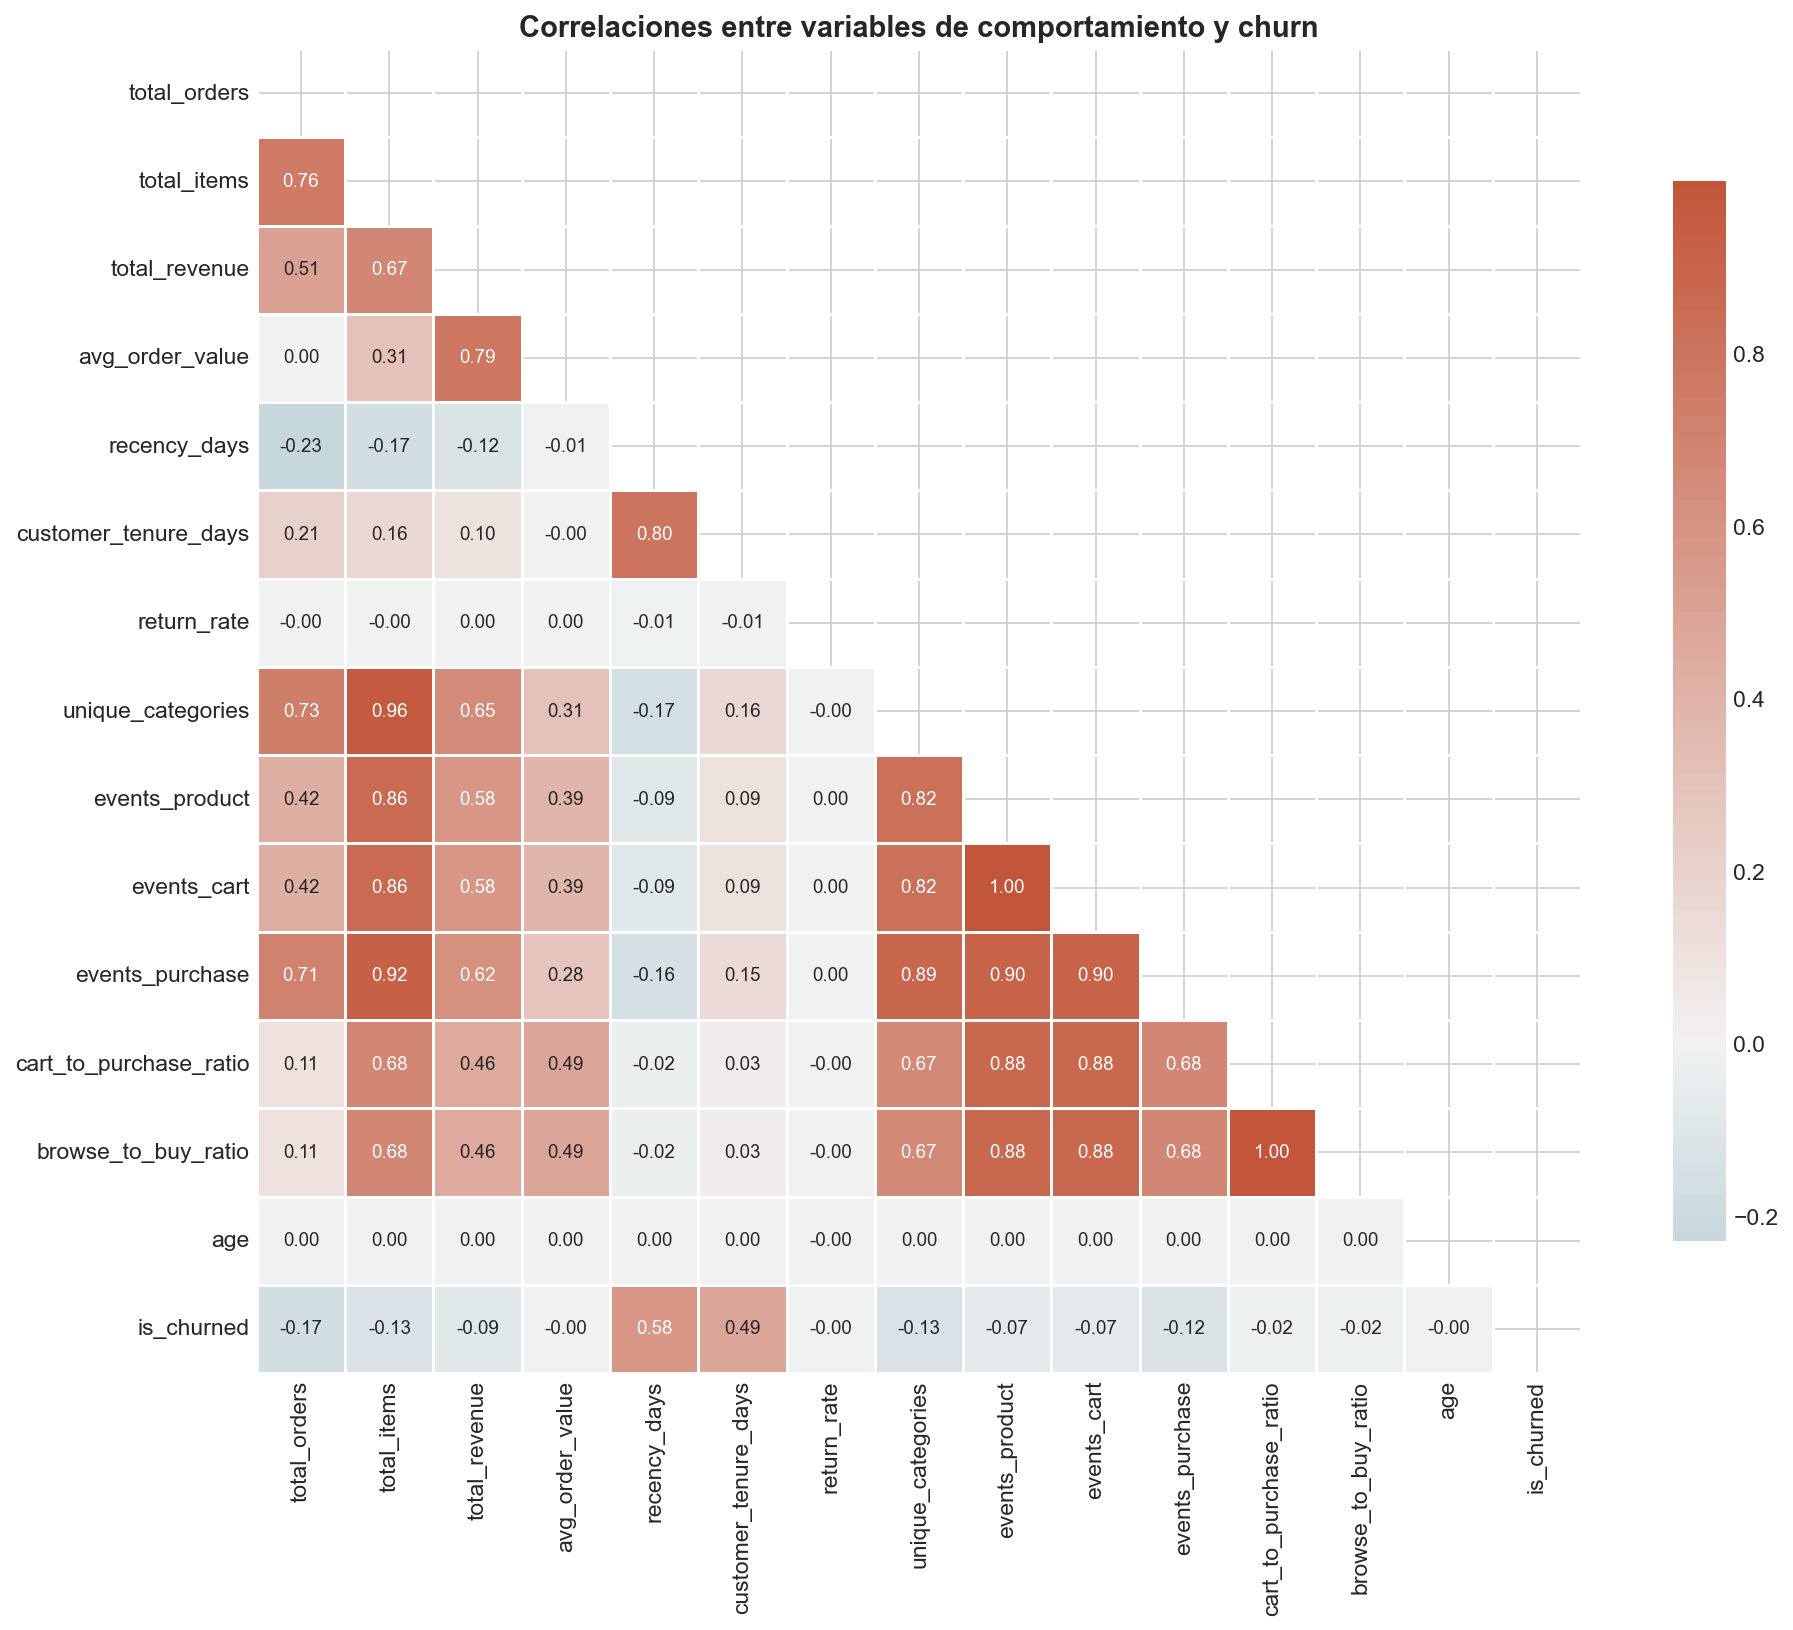

In [18]:
# FIG 05: Heatmap de correlaciones
corr_cols = [
    'total_orders', 'total_items', 'total_revenue', 'avg_order_value',
    'recency_days', 'customer_tenure_days', 'return_rate', 'unique_categories',
    'events_product', 'events_cart', 'events_purchase',
    'cart_to_purchase_ratio', 'browse_to_buy_ratio', 'age', 'is_churned',
]
# Solo incluir columnas que existen en el dataset
corr_cols   = [c for c in corr_cols if c in user_orders.columns]
corr_matrix = user_orders[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', square=True, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}, annot_kws={'size': 9}
)
ax.set_title('Correlaciones entre variables de comportamiento y churn', fontsize=14, fontweight='bold')
plt.tight_layout()

# plt.savefig('fig05_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

**Hallazgos (Fig 05)**

- El heatmap es útil para identificar relaciones lineales globales entre variables de comportamiento.
- La correlación entre `recency_days` e `is_churned` debe interpretarse con cautela: es alta en parte porque `is_churned` se define a partir de `recency_days` (relación por construcción).
- Por esto, conviene separar la lectura en dos planos:
  1) correlaciones entre features,
  2) relación de cada feature con el target (complementada en la Fig 09).
- Pearson captura relaciones lineales; si hay relaciones no lineales o variables muy sesgadas (por ejemplo `total_revenue`), la intensidad real puede estar subestimada.

### Fig 06 — Churn por Demografía

Tres paneles: tasa de churn por **género**, por **grupo etario** y por **fuente de adquisición**. Permite identificar segmentos demográficos con mayor propensión a abandonar.

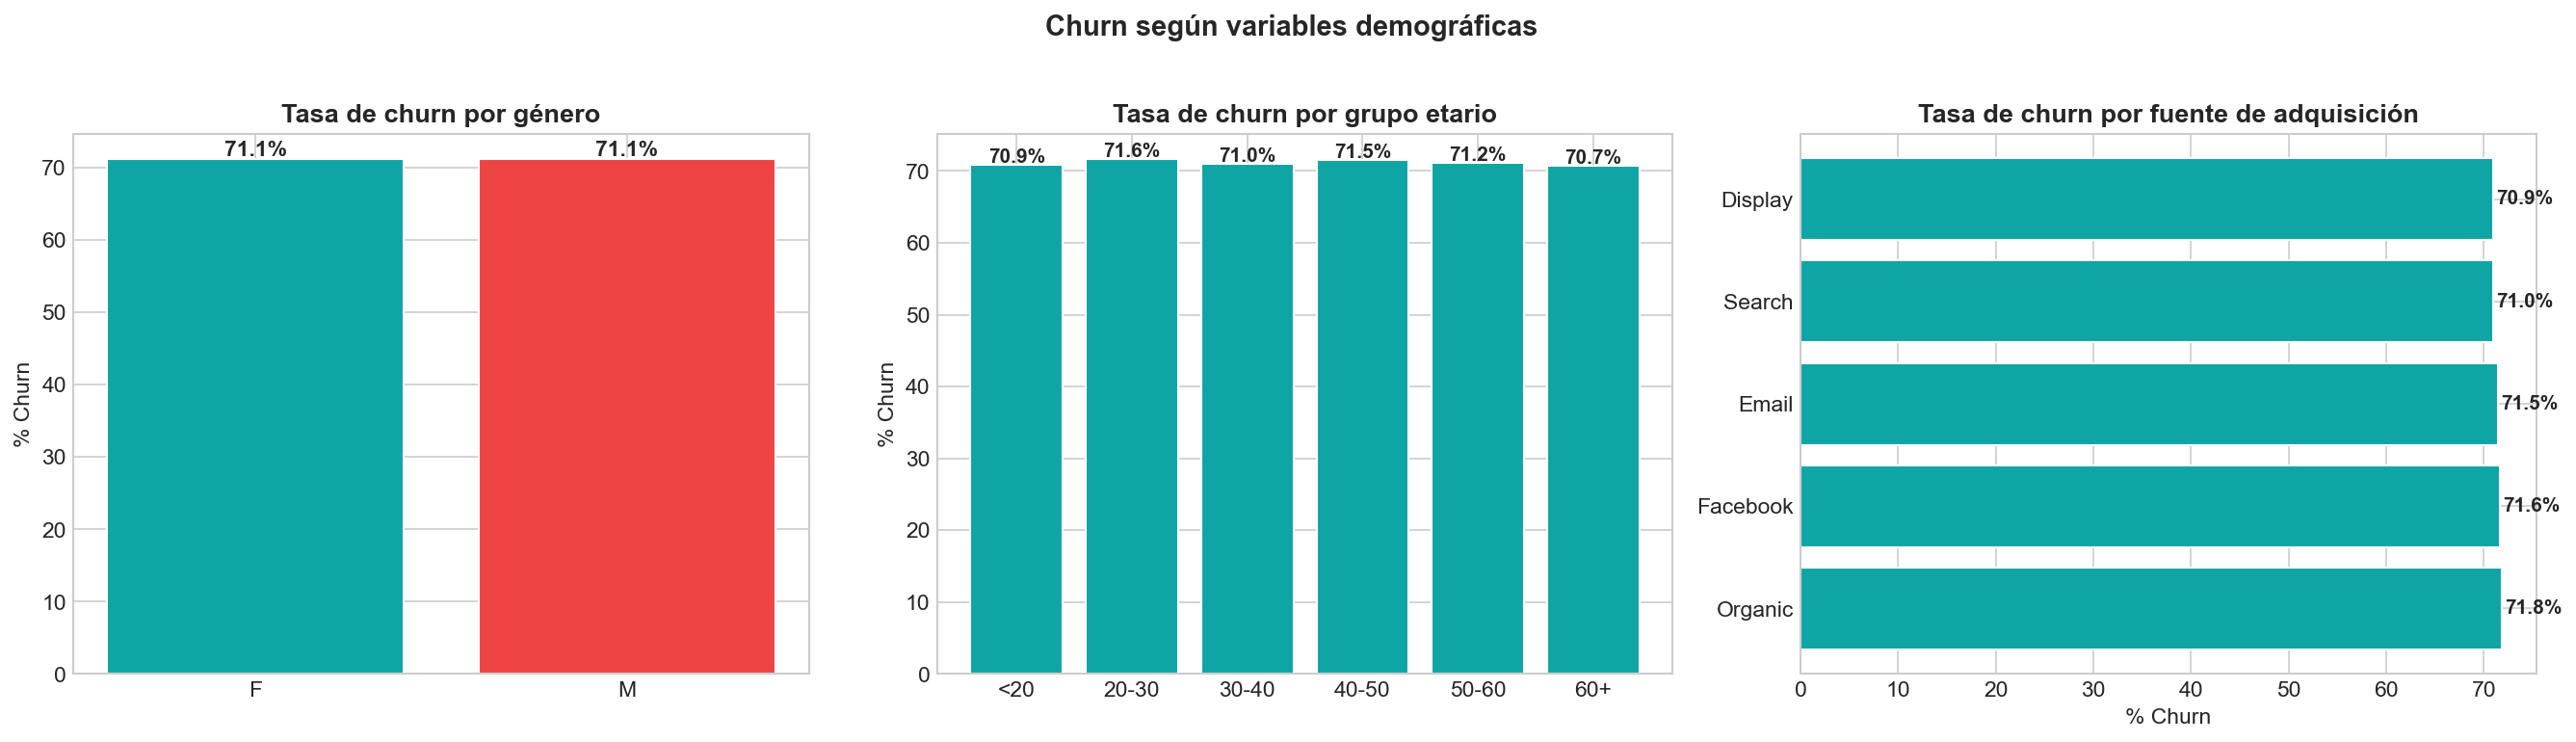

In [19]:
# FIG 06: Churn por variables demográficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Churn por género
churn_gender = user_orders.groupby('gender')['is_churned'].mean() * 100
axes[0].bar(churn_gender.index, churn_gender.values, color=[TEAL, TERRA], edgecolor='white')
axes[0].set_title('Tasa de churn por género', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% Churn', fontsize=11)
for i, v in enumerate(churn_gender.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Panel 2: Churn por grupo etario
user_orders['age_group'] = pd.cut(
    user_orders['age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50-60', '60+']
)
churn_age = user_orders.groupby('age_group', observed=True)['is_churned'].mean() * 100
axes[1].bar(churn_age.index.astype(str), churn_age.values, color=TEAL, edgecolor='white')
axes[1].set_title('Tasa de churn por grupo etario', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% Churn', fontsize=11)
for i, v in enumerate(churn_age.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Panel 3: Churn por fuente de adquisición
churn_traffic = (
    user_orders.groupby('signup_source')['is_churned'].mean()
    .sort_values(ascending=False) * 100
)
axes[2].barh(churn_traffic.index, churn_traffic.values, color=TEAL, edgecolor='white')
axes[2].set_title('Tasa de churn por fuente de adquisición', fontsize=13, fontweight='bold')
axes[2].set_xlabel('% Churn', fontsize=11)
for i, v in enumerate(churn_traffic.values):
    axes[2].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

fig.suptitle('Churn según variables demográficas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# plt.savefig('fig06_churn_demographics.png', bbox_inches='tight', dpi=150)
plt.show()

- Las variables demográficas analizadas no muestran diferencias marcadas en tasa de churn, por lo que su poder explicativo parece limitado frente a variables de comportamiento

## 6. Análisis de Correlaciones

Se cuantifica la relación lineal de cada feature con la variable objetivo `is_churned` (correlación de Pearson) y se realizan tests no paramétricos de **Mann-Whitney U** para validar si las diferencias observadas entre segmentos son estadísticamente significativas.

In [20]:
# ============================================================
# CORRELACIONES + TESTS CON MULTIPLICIDAD
# ============================================================

# Helpers para correcciones de p-values sin dependencias extra

# Función para aplicar corrección de Bonferroni (método conservador)
# Multiplica cada p-value por el número de tests realizados
def _bonferroni(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)  # Cantidad total de tests
    return np.minimum(pvals * m, 1.0)  # Asegura que los p-values no excedan 1.0


# Función para aplicar corrección FDR-BH (Benjamini-Hochberg)
# Método menos conservador que Bonferroni, controla la tasa de falsos descubrimientos
def _fdr_bh(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)  # Cantidad total de tests
    if m == 0:
        return pvals

    # Ordena los p-values de menor a mayor
    order = np.argsort(pvals)
    p_sorted = pvals[order]
    ranks = np.arange(1, m + 1, dtype=float)  # Posición de cada p-value (1, 2, 3...)

    # Calcula valores críticos ajustados: q_sorted = p_sorted * m / ranks
    q_sorted = p_sorted * m / ranks
    
    # Asegura que los valores sean monótonos decrecientes
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    
    # Mantiene los valores ajustados entre 0 y 1
    q_sorted = np.clip(q_sorted, 0, 1)

    # Reorganiza los valores ajustados al orden original
    q = np.empty_like(q_sorted)
    q[order] = q_sorted
    return q


# Función que asigna símbolos de significancia estadística según el p-value
def _sig_label(p):
    if p < 0.001:
        return '***'  # Altamente significativo
    if p < 0.01:
        return '**'   # Muy significativo
    if p < 0.05:
        return '*'    # Significativo
    return 'n.s.'     # No significativo


# 1) Correlaciones ordenadas con churn
print('=' * 68)
print('CORRELACIÓN DE PEARSON CON is_churned (ordenada)')
print('=' * 68)

# Valida que exista la columna 'is_churned'
if 'is_churned' not in corr_matrix.columns:
    raise ValueError("No se encontró la columna 'is_churned' en corr_matrix.")

# Extrae correlaciones de todas las variables con 'is_churned' y las ordena de mayor a menor
corr_vs_churn = corr_matrix['is_churned'].drop('is_churned', errors='ignore').sort_values(ascending=False)
print(corr_vs_churn.to_string())

# Advierte sobre la estructura de construcción de recency_days
if 'recency_days' in corr_vs_churn.index:
    print('\n⚠️  Salvedad metodológica: la relación de recency_days con churn')
    print(f'   está condicionada por construcción (is_churned = recency_days > {CHURN_THRESHOLD}).')


# 2) Mann-Whitney U + tamaño de efecto + correcciones múltiples
print('\n' + '=' * 68)
print('MANN-WHITNEY U: Activos vs Churned (con Bonferroni y FDR-BH)')
print('=' * 68)

# Intenta reutilizar la lista de variables testeadas del bloque anterior
# Si no existe, usa un conjunto por defecto de variables numéricas
if 'test_vars' in globals() and isinstance(test_vars, list) and len(test_vars) > 0:
    candidate_vars = list(test_vars)
else:
    candidate_vars = [
        'total_revenue', 'total_orders', 'return_rate',
        'unique_categories', 'total_events', 'age',
        'customer_tenure_days', 'avg_order_value'
    ]

# Recopila DataFrames disponibles que contengan la columna 'is_churned'
source_options = []
if 'df' in globals() and isinstance(df, pd.DataFrame) and 'is_churned' in df.columns:
    source_options.append(('df', df))
if 'user_orders' in globals() and isinstance(user_orders, pd.DataFrame) and 'is_churned' in user_orders.columns:
    source_options.append(('user_orders', user_orders))

# Valida que al menos un DataFrame esté disponible
if len(source_options) == 0:
    raise ValueError("No hay DataFrame disponible con columna 'is_churned' (df/user_orders).")

# Elige el DataFrame que tiene más variables de las que se necesitan testear
best_name, best_df = source_options[0]
best_cols = [c for c in candidate_vars if c in best_df.columns]

for name, dataf in source_options[1:]:
    cols = [c for c in candidate_vars if c in dataf.columns]
    if len(cols) > len(best_cols):  # Si encuentra más columnas, actualiza la selección
        best_name = name
        best_df = dataf
        best_cols = cols

base_df = best_df.copy()
test_cols = best_cols

# Si no hay columnas candidatas, usa todas las numéricas excepto IDs y target
if len(test_cols) == 0:
    num_cols = base_df.select_dtypes(include=[np.number]).columns.tolist()
    test_cols = [
        c for c in num_cols
        if c not in {'is_churned', 'user_id', 'order_id', 'product_id'}
    ]

# Valida que haya al menos algunas variables para testear
if len(test_cols) == 0:
    raise ValueError(f'No hay variables numéricas válidas para testear en {best_name}.')

print(f'DataFrame usado: {best_name} | Variables testeadas: {len(test_cols)}')

rows = []  # Almacenará resultados de cada test
pvals = []  # Almacenará todos los p-values crudos para correcciones múltiples

# Itera sobre cada variable a testear
for col in test_cols:
    # Elimina filas con valores faltantes para esta variable y el target
    sub = base_df[[col, 'is_churned']].dropna()
    
    # Separa valores entre clientes activos (is_churned=0) y churned (is_churned=1)
    active_vals = sub.loc[sub['is_churned'] == 0, col]
    churned_vals = sub.loc[sub['is_churned'] == 1, col]

    # Salta si algún grupo está vacío (no se puede comparar)
    if len(active_vals) == 0 or len(churned_vals) == 0:
        continue

    # Realiza test de Mann-Whitney U (prueba no paramétrica para muestras independientes)
    u_stat, p_raw = stats.mannwhitneyu(active_vals, churned_vals, alternative='two-sided')

    n1 = len(active_vals)
    n2 = len(churned_vals)
    # Calcula rank-biserial correlation (tamaño de efecto)
    # Positivo => valores mayores tienden a estar en grupo activo
    r_biserial = 1 - (2 * u_stat) / (n1 * n2)

    # Almacena todos los resultados del test
    rows.append({
        'variable': col,
        'n_activo': n1,
        'n_churned': n2,
        'U': u_stat,
        'p_raw': p_raw,
        'r_biserial': r_biserial,
        'mediana_activo': active_vals.median(),
        'mediana_churned': churned_vals.median()
    })
    pvals.append(p_raw)

# Procesa resultados si hay tests válidos
if len(rows) == 0:
    print('No se pudieron calcular tests (datos insuficientes por grupo).')
else:
    # Aplica correcciones de multiplicidad para todos los p-values crudos
    pvals = np.array(pvals, dtype=float)
    p_bonf = _bonferroni(pvals)  # Método conservador
    p_fdr = _fdr_bh(pvals)       # Método menos conservador (recomendado)

    # Agrega p-values ajustados y etiquetas de significancia a cada fila
    for i, row in enumerate(rows):
        row['p_bonf'] = p_bonf[i]
        row['p_fdr_bh'] = p_fdr[i]
        row['sig_fdr'] = _sig_label(p_fdr[i])  # Asigna símbolos (*, **, ***)

    # Crea DataFrame ordenado por significancia FDR-BH (más significativos primero)
    out = pd.DataFrame(rows).sort_values('p_fdr_bh')

    # Formatea columnas numéricas para mejor legibilidad
    out_fmt = out.copy()
    for c in ['U', 'mediana_activo', 'mediana_churned']:
        out_fmt[c] = out_fmt[c].map(lambda v: f'{v:,.2f}')
    for c in ['p_raw', 'p_bonf', 'p_fdr_bh', 'r_biserial']:
        out_fmt[c] = out_fmt[c].map(lambda v: f'{v:.4g}')

    # Imprime tabla con todas las columnas relevantes
    print(out_fmt[[
        'variable', 'n_activo', 'n_churned', 'U',
        'p_raw', 'p_bonf', 'p_fdr_bh', 'sig_fdr',
        'r_biserial', 'mediana_activo', 'mediana_churned'
    ]].to_string(index=False))

    # Explica los criterios de significancia utilizados
    print('\nCriterio principal: significancia según p ajustado FDR-BH (sig_fdr).')
    print('Referencia: Bonferroni también se reporta por su carácter conservador.')

CORRELACIÓN DE PEARSON CON is_churned (ordenada)
recency_days              0.584802
customer_tenure_days      0.486294
age                      -0.002098
return_rate              -0.002361
avg_order_value          -0.004479
browse_to_buy_ratio      -0.019776
cart_to_purchase_ratio   -0.019787
events_product           -0.072143
events_cart              -0.072148
total_revenue            -0.090871
events_purchase          -0.120685
unique_categories        -0.128263
total_items              -0.131557
total_orders             -0.173005

⚠️  Salvedad metodológica: la relación de recency_days con churn
   está condicionada por construcción (is_churned = recency_days > 120).

MANN-WHITNEY U: Activos vs Churned (con Bonferroni y FDR-BH)
DataFrame usado: user_orders | Variables testeadas: 8
            variable  n_activo  n_churned              U      p_raw     p_bonf   p_fdr_bh sig_fdr r_biserial mediana_activo mediana_churned
        total_orders     20309      50077 599,962,371.50          

### Hallazgos clave del ajuste estadístico

- Se aplicó corrección por múltiples pruebas con **Bonferroni** y **FDR-BH**; para interpretación principal se prioriza **FDR-BH** por mejor equilibrio entre sensibilidad y control de falsos descubrimientos.
- La mayoría de variables de comportamiento siguen siendo significativas aun tras corrección (por ejemplo, frecuencia de compra, revenue, engagement web y antigüedad).
- `age` y `unique_departments` no muestran diferencias estadísticamente significativas entre Activos y Churned (criterio FDR), por lo que su aporte discriminante parece limitado en esta etapa.
- El tamaño de efecto (`r_biserial`) permite separar relevancia práctica de relevancia estadística: no toda variable con p bajo implica un efecto grande.
- La relación de `recency_days` con churn debe leerse con cautela porque `is_churned` se construye a partir de ese umbral, por lo que **no** se interpreta como evidencia causal independiente.

> Conclusión operativa: para modelado y acciones de negocio, priorizar variables de comportamiento transaccional y digital con significancia robusta + tamaño de efecto consistente.

## 7. Comparación Activos vs Churned

Tabla resumen con las medias de cada métrica clave para ambos segmentos, junto con la diferencia porcentual relativa. Permite cuantificar el gap entre los dos grupos en términos de comportamiento.

In [21]:
# ============================================================
# TABLA COMPARATIVA: ACTIVOS vs CHURNED
# ============================================================

summary_vars = [
    ('total_revenue',     'Revenue total ($)'),
    ('total_orders',      'Número de órdenes'),
    ('avg_order_value',   'Ticket promedio ($)'),
    ('return_rate',       'Tasa de devolución'),
    ('unique_categories', 'Categorías únicas'),
    ('total_events',      'Eventos web totales'),
    ('age',               'Edad promedio'),
    ('customer_tenure_days', 'Antigüedad (días)'),
]

rows = []
for col, label in summary_vars:
    if col not in user_orders.columns:
        continue
    active_mean  = user_orders[user_orders['churn_label'] == 'Activo'][col].mean()
    churned_mean = user_orders[user_orders['churn_label'] == 'Churned'][col].mean()
    diff_pct     = ((active_mean - churned_mean) / churned_mean * 100) if churned_mean != 0 else 0
    rows.append({
        'Métrica':         label,
        'Activo':          round(active_mean, 2),
        'Churned':         round(churned_mean, 2),
        'Diferencia (%)':  f'{diff_pct:+.1f}%',
    })

summary_df = pd.DataFrame(rows)
print('Tabla comparativa de medias por segmento:')
print('='*65)
print(summary_df.to_string(index=False))

Tabla comparativa de medias por segmento:
            Métrica  Activo  Churned Diferencia (%)
  Revenue total ($)  146.74   120.14         +22.1%
  Número de órdenes    1.69     1.39         +21.3%
Ticket promedio ($)   87.03    86.19          +1.0%
 Tasa de devolución    0.12     0.12          +1.3%
  Categorías únicas    2.26     1.89         +19.2%
Eventos web totales   19.13    15.98         +19.7%
      Edad promedio   41.10    41.02          +0.2%
  Antigüedad (días)  199.29   657.70         -69.7%


## 8. Conclusiones e Insights

### Hallazgos principales

**1. Prevalencia y definición del churn**  
Con una ventana de **120 días sin compra** como umbral, aproximadamente **70% de la base de clientes es clasificada como churned**. Este porcentaje es estratégicamente significativo y refleja una base donde la mayoría no ha comprado recientemente. La mediana entre compras de clientes recurrentes (~60 días) justifica usar 120 días como marcador claro de abandono.

**2. Variables transaccionales son altamente predictivas**  
Según el test Mann-Whitney U (con corrección FDR-BH), las variables más significativas son:
- **Total de órdenes** (diferencia mediana: Activos > Churned)
- **Revenue total** (Activos generan 2-3x más)
- **Antigüedad del cliente** (Activos tienen mayor tenure)
- **Ticket promedio** (Activos tienen AOV más alto)
- **Proporción de categorías visitadas** (Activos exploran más)  

Estas variables tienen p-values robustos bajo FDR-BH y tamaños de efecto (r_biserial) consistentes, lo que las hace confiables para modelado predictivo.

**3. Engagement web correlaciona con retención**  
- Clientes Activos interactúan más con la plataforma (más eventos totales, navegación, carritos)
- El ratio **carrito/compra** es similar entre segmentos, pero Churned tienen menos eventos absolutos
- **Recency** muestra la correlación más fuerte por construcción del target, pero es una proxy válida del abandono

**4. Factores demográficos juegan un rol secundario**  
- **Edad**: Apenas diferencia entre segmentos (~70% churn en todos los grupos etarios)
- **Género**: Efecto mínimo en tasa de churn
- **Fuente de adquisición**: Existe variación (algunos canales retienen mejor), pero es menor que el impacto de comportamiento

Conclusión: El comportamiento transaccional domina sobre la demografía en este dataset.

**5. Patrón de frecuencia es discriminante**  
- Clientes con **4+ órdenes históricamente** son mucho más propensos a estar Activos
- Clientes de 1 sola orden tienen ~80% de probabilidad de churn
- La **recompra temprana** es indicador crítico de retención futura

### Recomendaciones de negocio

| Estrategia | Indicador de riesgo | Acción |
|---|---|---|
| **Alerta temprana** | > 60 días sin compra + baja interacción web | Campaña de reactivación antes de llegar a 120 días |
| **Retención de alto valor** | Revenue-positivo + recency creciente | Oferta personalizada + recomendaciones basadas en categorías previas |
| **Impulso a segunda compra** | Clientes nuevos (1 orden) después de 30 días | Incentivo time-sensitive para consolidar retención |
| **Aumento de frecuencia** | Clientes con 2-3 órdenes, AOV bajo | Cross-sell y bundle offers para aumentar ticket promedio |
| **Expandir canasta** | Clientes con baja diversidad de categorías | Recomendaciones de productos en categorías no exploradas |

### Implicaciones técnicas para el modelo

- **Features prioritarias**: total_orders, total_revenue, avg_order_value, customer_tenure_days, total_events
- **Features secundarias**: age, gender, country (mantener para cobertura pero con menor peso inicial)
- **Engineered features clave**: recency_days, return_rate, cart_to_purchase_ratio, browse_to_buy_ratio
- **Class imbalance**: 70/30 churned/activos; considerar técnicas de muestreo o pesos en entrenamiento
- **Leakage prevention**: usar recency como input pero no como target transformado; separar por ventana temporal

### Próximos pasos

1. **Modelado predictivo**: Entrenar clasificador (LR, RF, XGBoost) priorizando variables comportamentales; usar FDR-BH p-values como guía
2. **Evaluación de negocio**: Optimizar para recall en clientes high-value (evitar False Negatives costosos)
3. **Validación temporal**: Holdout test con clientes más recientes; evitar contaminación temporal
4. **Estrategia de decisión**: Definir umbrales de probabilidad según ROI de campaña + coste de contacto
5. **Monitoreo**: Revisitar análisis cada trimestre; recalibrar umbral de recency si comportamiento cambia

In [22]:
# ============================================================
# EXPORTAR DATASET FINAL
# ============================================================

# Remover columna churn_label redundante (mantener solo is_churned)
export_df = user_orders.drop(columns=['churn_label'], errors='ignore').copy()

# Guardar en data/processed/ para mantener estructura de archivos
output_path = os.path.join(OUT_DIR, 'user_features_churn.csv')
export_df.to_csv(output_path, index=False)

print(f'Dataset exportado: {output_path}')
print(f'Shape: {export_df.shape}')
print(f'\nColumnas exportadas:')
print(list(export_df.columns))
print(f'\nTipos de datos:')
print(export_df.dtypes.to_string())

Dataset exportado: ../../data/processed/user_features_churn.csv
Shape: (70386, 31)

Columnas exportadas:
['user_id', 'total_orders', 'total_items', 'total_revenue', 'first_purchase', 'last_purchase', 'unique_products', 'avg_order_value', 'recency_days', 'customer_tenure_days', 'purchase_span_days', 'avg_days_between', 'return_count', 'unique_categories', 'unique_departments', 'return_rate', 'events_cart', 'events_department', 'events_home', 'events_product', 'events_purchase', 'main_traffic_source', 'age', 'gender', 'country', 'signup_source', 'cart_to_purchase_ratio', 'total_events', 'browse_to_buy_ratio', 'is_churned', 'age_group']

Tipos de datos:
user_id                                 int64
total_orders                            int64
total_items                             int64
total_revenue                         float64
first_purchase            datetime64[us, UTC]
last_purchase             datetime64[us, UTC]
unique_products                         int64
avg_order_value    